In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/znanstveno/projekt/PJM(AEP)_energy_dataset.csv')
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime

print("="*100)
print("🔋 KREIRANJE KOMPLETNOG DATASETA - PJM ENERGY + VREMENSKE PODATKE")
print("="*100)

# ============================================
# 1. UČITAJ PJM ENERGY DATASET IZ GOOGLE DRIVE
# ============================================

print("\n📊 1. UČITAVANJE PJM ENERGETSKIH PODATAKA...")
print("-" * 100)

df_energy = pd.read_csv('/content/drive/MyDrive/znanstveno/projekt/PJM(AEP)_energy_dataset.csv')
df_energy['Datetime'] = pd.to_datetime(df_energy['Datetime'])

print(f"✅ Učitano {len(df_energy):,} satnih zapisa")
print(f"   Period: {df_energy['Datetime'].min()} → {df_energy['Datetime'].max()}")
print(f"   Prosječna potrošnja: {df_energy['PJME_MW'].mean():.0f} MW")
print(f"\nPrvih 5 redaka:")
print(df_energy.head())

# ============================================
# 2. PREUZIMANJE VREMENSKIH PODATAKA - PENNSYLVANIA
# ============================================

def get_weather_data_pennsylvania(start_date, end_date):
    """
    Preuzima kompletne vremenske podatke za Pennsylvaniju s Open-Meteo
    """
    print("\n🌤️  PREUZIMANJE VREMENSKIH PODATAKA...")
    print("-" * 100)

    # Pennsylvania koordinate (Harrisburg - centar PJM regije)
    lat, lon = 40.2732, -76.8867

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            # TEMPERATURA
            "temperature_2m",
            "apparent_temperature",
            "relative_humidity_2m",

            # OBORINE
            "precipitation",
            "rain",
            "snowfall",

            # VJETAR
            "wind_speed_10m",
            "wind_direction_10m",
            "wind_gusts_10m",

            # SUNCE I RADIJACIJA
            "shortwave_radiation",
            "cloud_cover",

            # TLAK
            "surface_pressure",
        ],
        "timezone": "America/New_York"
    }

    try:
        print(f"📍 Lokacija: Harrisburg, Pennsylvania")
        print(f"📅 Period: {start_date} → {end_date}")
        print(f"⏳ Preuzimam... (može trajati 1-2 minute)")

        response = requests.get(url, params=params, timeout=60)

        if response.status_code == 200:
            data = response.json()
            df = pd.DataFrame(data['hourly'])
            df['time'] = pd.to_datetime(df['time'])

            print(f"✅ Preuzeto {len(df):,} satnih vremenskih zapisa")
            print(f"   Prosječna temperatura: {df['temperature_2m'].mean():.1f}°C")
            print(f"   Ukupna kiša: {df['rain'].sum():.0f} mm")
            print(f"   Prosječan vjetar: {df['wind_speed_10m'].mean():.1f} km/h")

            return df
        else:
            print(f"❌ Greška: Status kod {response.status_code}")
            return None

    except Exception as e:
        print(f"❌ Greška pri preuzimanju: {e}")
        return None

# Preuzmi vremenske podatke za cijeli period PJM dataseta
start_date = df_energy['Datetime'].min().strftime('%Y-%m-%d')
end_date = df_energy['Datetime'].max().strftime('%Y-%m-%d')

df_weather = get_weather_data_pennsylvania(start_date, end_date)

if df_weather is not None:
    print("\n✅ Vremenske podatke uspješno preuzeti!")
else:
    print("\n❌ Greška kod preuzimanja vremenskih podataka!")

🔋 KREIRANJE KOMPLETNOG DATASETA - PJM ENERGY + VREMENSKE PODATKE

📊 1. UČITAVANJE PJM ENERGETSKIH PODATAKA...
----------------------------------------------------------------------------------------------------
✅ Učitano 145,366 satnih zapisa
   Period: 2002-01-01 01:00:00 → 2018-08-03 00:00:00
   Prosječna potrošnja: 32080 MW

Prvih 5 redaka:
             Datetime  PJME_MW
0 2002-12-31 01:00:00  26498.0
1 2002-12-31 02:00:00  25147.0
2 2002-12-31 03:00:00  24574.0
3 2002-12-31 04:00:00  24393.0
4 2002-12-31 05:00:00  24860.0

🌤️  PREUZIMANJE VREMENSKIH PODATAKA...
----------------------------------------------------------------------------------------------------
📍 Lokacija: Harrisburg, Pennsylvania
📅 Period: 2002-01-01 → 2018-08-03
⏳ Preuzimam... (može trajati 1-2 minute)
✅ Preuzeto 145,416 satnih vremenskih zapisa
   Prosječna temperatura: 12.0°C
   Ukupna kiša: 16053 mm
   Prosječan vjetar: 10.1 km/h

✅ Vremenske podatke uspješno preuzeti!


In [ ]:
import pandas as pd
import numpy as np

# ============================================
# 3. SPAJANJE I AGREGACIJA PODATAKA
# ============================================

print("\n🔗 3. SPAJANJE ENERGETSKIH I VREMENSKIH PODATAKA...")
print("-" * 100)

# Preimenuj kolone za jasnoću
df_weather = df_weather.rename(columns={'time': 'datetime'})
df_energy = df_energy.rename(columns={'Datetime': 'datetime'})

# Spoji podatke po datetime
df_merged = df_energy.merge(df_weather, on='datetime', how='inner')

print(f"✅ Spojeno {len(df_merged):,} satnih zapisa")
print(f"   Kolona: {len(df_merged.columns)}")

# Agregacija na dnevni nivo
print("\n🔄 Agregacija na dnevni nivo...")

df_merged['date'] = df_merged['datetime'].dt.date
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Dnevna agregacija
daily_df = df_merged.groupby('date').agg({
    # Energija
    'PJME_MW': ['mean', 'max', 'min', 'std'],

    # Temperatura
    'temperature_2m': ['mean', 'max', 'min'],
    'apparent_temperature': ['mean', 'max', 'min'],
    'relative_humidity_2m': 'mean',

    # Oborine
    'precipitation': 'sum',
    'rain': 'sum',
    'snowfall': 'sum',

    # Vjetar
    'wind_speed_10m': ['mean', 'max'],
    'wind_direction_10m': 'mean',
    'wind_gusts_10m': 'max',

    # Sunce
    'shortwave_radiation': 'sum',
    'cloud_cover': 'mean',

    # Tlak
    'surface_pressure': 'mean'
}).reset_index()

# Flatten column names
daily_df.columns = ['_'.join(col).strip('_') for col in daily_df.columns.values]
daily_df = daily_df.rename(columns={'date_': 'date'})

print(f"✅ Agregirano na {len(daily_df):,} dana")
print(f"\nPrvih 5 redaka:")
print(daily_df.head())

# ============================================
# 4. DODAVANJE NAPREDNIH ZNAČAJKI
# ============================================

def create_advanced_features(df):
    """
    Kreira napredne značajke za ML model - PRILAGOĐENO ZA PENNSYLVANIA
    """
    print("\n🔧 KREIRANJE NAPREDNIH ZNAČAJKI...")
    print("-" * 100)

    df = df.copy()

    # ===== VREMENSKE ZNAČAJKE =====
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['day_of_year'] = df['date'].dt.dayofyear

    # Boolean značajke
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_monday'] = (df['dayofweek'] == 0).astype(int)
    df['is_friday'] = (df['dayofweek'] == 4).astype(int)

    # Godišnja doba
    df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)
    df['is_spring'] = df['month'].isin([3, 4, 5]).astype(int)
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    df['is_autumn'] = df['month'].isin([9, 10, 11]).astype(int)

    # Praznici u USA
    holidays_usa = [
        # Glavne značajke koje utječu na potrošnju
    ]
    df['is_holiday'] = 0  # Dodaj kasnije ako želiš

    # ===== TEMPERATURNE ZNAČAJKE =====
    df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
    df['apparent_temp_range'] = df['apparent_temperature_max'] - df['apparent_temperature_min']

    # Heating & Cooling Degree Days
    df['heating_degree_days'] = np.maximum(0, 18 - df['temperature_2m_mean'])
    df['cooling_degree_days'] = np.maximum(0, df['temperature_2m_mean'] - 24)

    # Temperatura kategorije (Fahrenheit zona - konvertiraj u Celsius)
    df['is_freezing'] = (df['temperature_2m_mean'] < 0).astype(int)
    df['is_cold'] = ((df['temperature_2m_mean'] >= 0) & (df['temperature_2m_mean'] < 10)).astype(int)
    df['is_mild'] = ((df['temperature_2m_mean'] >= 10) & (df['temperature_2m_mean'] < 20)).astype(int)
    df['is_warm'] = ((df['temperature_2m_mean'] >= 20) & (df['temperature_2m_mean'] < 28)).astype(int)
    df['is_hot'] = (df['temperature_2m_mean'] >= 28).astype(int)

    # ===== OBORINSKE ZNAČAJKE =====
    df['has_precipitation'] = (df['precipitation_sum'] > 0).astype(int)
    df['has_rain'] = (df['rain_sum'] > 0).astype(int)
    df['has_snow'] = (df['snowfall_sum'] > 0).astype(int)
    df['heavy_rain'] = (df['rain_sum'] > 10).astype(int)

    # ===== VJETROVNE ZNAČAJKE =====
    df['is_windy'] = (df['wind_speed_10m_max'] > 30).astype(int)
    df['is_very_windy'] = (df['wind_speed_10m_max'] > 50).astype(int)
    df['wind_gust_ratio'] = df['wind_gusts_10m_max'] / (df['wind_speed_10m_max'] + 0.1)

    # ===== SUNČANE ZNAČAJKE =====
    df['is_cloudy'] = (df['cloud_cover_mean'] > 70).astype(int)

    # ===== LAG ZNAČAJKE =====
    for lag in [1, 2, 3, 7]:
        df[f'temp_lag_{lag}d'] = df['temperature_2m_mean'].shift(lag)
        df[f'precip_lag_{lag}d'] = df['precipitation_sum'].shift(lag)
        df[f'wind_lag_{lag}d'] = df['wind_speed_10m_max'].shift(lag)
        df[f'energy_lag_{lag}d'] = df['PJME_MW_mean'].shift(lag)

    # ===== ROLLING ZNAČAJKE =====
    for window in [3, 7, 14]:
        df[f'temp_rolling_{window}d'] = df['temperature_2m_mean'].rolling(window, min_periods=1).mean()
        df[f'precip_rolling_{window}d'] = df['precipitation_sum'].rolling(window, min_periods=1).sum()
        df[f'temp_rolling_std_{window}d'] = df['temperature_2m_mean'].rolling(window, min_periods=1).std()
        df[f'energy_rolling_{window}d'] = df['PJME_MW_mean'].rolling(window, min_periods=1).mean()

    # ===== INTERAKCIJE =====
    df['temp_x_wind'] = df['temperature_2m_mean'] * df['wind_speed_10m_max']
    df['cold_and_wet'] = ((df['temperature_2m_mean'] < 10) & (df['rain_sum'] > 5)).astype(int)
    df['hot_and_humid'] = ((df['temperature_2m_mean'] > 25) & (df['cloud_cover_mean'] > 50)).astype(int)

    # ===== CIKLIČNE ZNAČAJKE =====
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    print(f"✅ Kreirano ukupno {len(df.columns)} značajki")

    return df

# POKRENI
df_final = create_advanced_features(daily_df)

# Target varijabla
target_col = 'PJME_MW_mean'

print(f"\n✅ FINALNI DATASET KREIRAN!")
print(f"   Redaka: {len(df_final):,}")
print(f"   Stupaca: {len(df_final.columns)}")
print(f"   Target: {target_col}")
print(f"\nPrvih 5 redaka:")
print(df_final.head())

# Spremi
output_file = '/content/drive/MyDrive/znanstveno/projekt/pjm_energy_weather_complete.csv'
df_final.to_csv(output_file, index=False)
print(f"\n💾 Spremljeno u: {output_file}")


🔗 3. SPAJANJE ENERGETSKIH I VREMENSKIH PODATAKA...
----------------------------------------------------------------------------------------------------
✅ Spojeno 145,366 satnih zapisa
   Kolona: 14

🔄 Agregacija na dnevni nivo...
✅ Agregirano na 6,059 dana

Prvih 5 redaka:
        date  PJME_MW_mean  PJME_MW_max  PJME_MW_min  PJME_MW_std  \
0 2002-01-01  31080.739130      35732.0      27899.0  2457.808359   
1 2002-01-02  34261.541667      40002.0      27301.0  4186.099554   
2 2002-01-03  34511.875000      39662.0      28106.0  3797.974429   
3 2002-01-04  33715.458333      38263.0      28122.0  3311.018272   
4 2002-01-05  30405.125000      34092.0      26669.0  2307.965909   

   temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
0            -3.947826                 0.6                -7.1   
1            -2.816667                 1.6                -5.6   
2            -2.516667                 2.0                -5.1   
3            -1.170833                 2.3    

In [ ]:
import pandas as pd
import numpy as np

# ============================================
# 5. FINALNI IZVJEŠTAJ O DATASETU
# ============================================

def print_dataset_report(df, target_col='PJME_MW_mean'):
    """
    Ispisuje detaljan izvještaj o datasetu
    """
    print("\n" + "="*100)
    print("📊 FINALNI DATASET - IZVJEŠTAJ")
    print("="*100)

    print(f"\n📅 VREMENSKI RASPON:")
    print(f"   Od: {df['date'].min().strftime('%d.%m.%Y')}")
    print(f"   Do: {df['date'].max().strftime('%d.%m.%Y')}")
    print(f"   Ukupno dana: {len(df)}")

    print(f"\n📏 DIMENZIJE:")
    print(f"   Redaka: {len(df):,}")
    print(f"   Stupaca: {len(df.columns)}")
    print(f"   Memorija: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\n⚡ POTROŠNJA ENERGIJE:")
    print(f"   Prosječna: {df[target_col].mean():,.0f} MW")
    print(f"   Minimalna: {df[target_col].min():,.0f} MW")
    print(f"   Maksimalna: {df[target_col].max():,.0f} MW")
    print(f"   Std. devijacija: {df[target_col].std():,.0f} MW")

    print(f"\n🌡️  TEMPERATURA:")
    print(f"   Prosječna: {df['temperature_2m_mean'].mean():.1f}°C")
    print(f"   Minimalna: {df['temperature_2m_min'].min():.1f}°C")
    print(f"   Maksimalna: {df['temperature_2m_max'].max():.1f}°C")

    print(f"\n🌧️  OBORINE:")
    print(f"   Ukupno kiše: {df['rain_sum'].sum():,.0f} mm")
    print(f"   Ukupno snijega: {df['snowfall_sum'].sum():,.0f} cm")
    print(f"   Dana s kišom: {df['has_rain'].sum()}")
    print(f"   Dana sa snijegom: {df['has_snow'].sum()}")

    print(f"\n💨 VJETAR:")
    print(f"   Prosječna brzina: {df['wind_speed_10m_mean'].mean():.1f} km/h")
    print(f"   Maksimalna brzina: {df['wind_speed_10m_max'].max():.1f} km/h")
    print(f"   Vjetrovitih dana (>30km/h): {df['is_windy'].sum()}")

    print(f"\n☀️  SUNCE I OBLAČNOST:")
    print(f"   Prosječna radijacija: {df['shortwave_radiation_sum'].mean():,.0f} J/m²")
    print(f"   Prosječna oblačnost: {df['cloud_cover_mean'].mean():.1f}%")
    print(f"   Oblačnih dana (>70%): {df['is_cloudy'].sum()}")

    print(f"\n🔍 KVALITETA PODATAKA:")
    missing = df.isnull().sum().sum()
    print(f"   Nedostajućih vrijednosti: {missing}")
    print(f"   Kompletnost: {(1 - missing/(len(df)*len(df.columns)))*100:.2f}%")

    print(f"\n📈 TOP 15 ZNAČAJKI (KORELACIJA S POTROŠNJOM):")
    numeric_df = df.select_dtypes(include=[np.number])
    correlations = numeric_df.corr()[target_col].abs().sort_values(ascending=False)[1:16]
    for i, (feature, corr) in enumerate(correlations.items(), 1):
        print(f"   {i:2d}. {feature:40s} {corr:.3f}")

# POKRENI IZVJEŠTAJ
print_dataset_report(df_final)

# Ukloni NaN vrijednosti (fillna backwards/forwards)
print("\n🧹 ČIŠĆENJE PODATAKA...")
df_final = df_final.fillna(method='bfill').fillna(method='ffill')

missing_after = df_final.isnull().sum().sum()
print(f"✅ Nedostajućih vrijednosti nakon čišćenja: {missing_after}")

# Finalno spremanje
output_file = '/content/drive/MyDrive/znanstveno/projekt/pjm_energy_weather_final.csv'
df_final.to_csv(output_file, index=False)

print("\n" + "="*100)
print("🎉 GOTOVO! FINALNI DATASET KREIRAN I SPREMLJEN!")
print("="*100)
print(f"📂 Lokacija: {output_file}")
print(f"📊 Redaka: {len(df_final):,}")
print(f"📊 Stupaca: {len(df_final.columns)}")
print(f"\n✅ Spreman za ML modeliranje!")


📊 FINALNI DATASET - IZVJEŠTAJ

📅 VREMENSKI RASPON:
   Od: 01.01.2002
   Do: 03.08.2018
   Ukupno dana: 6059

📏 DIMENZIJE:
   Redaka: 6,059
   Stupaca: 89
   Memorija: 3.96 MB

⚡ POTROŠNJA ENERGIJE:
   Prosječna: 32,080 MW
   Minimalna: 19,769 MW
   Maksimalna: 52,230 MW
   Std. devijacija: 4,686 MW

🌡️  TEMPERATURA:
   Prosječna: 12.0°C
   Minimalna: -22.0°C
   Maksimalna: 38.5°C

🌧️  OBORINE:
   Ukupno kiše: 16,027 mm
   Ukupno snijega: 1,151 cm
   Dana s kišom: 2599
   Dana sa snijegom: 539

💨 VJETAR:
   Prosječna brzina: 10.1 km/h
   Maksimalna brzina: 39.5 km/h
   Vjetrovitih dana (>30km/h): 86

☀️  SUNCE I OBLAČNOST:
   Prosječna radijacija: 4,027 J/m²
   Prosječna oblačnost: 59.3%
   Oblačnih dana (>70%): 2501

🔍 KVALITETA PODATAKA:
   Nedostajućih vrijednosti: 56
   Kompletnost: 99.99%

📈 TOP 15 ZNAČAJKI (KORELACIJA S POTROŠNJOM):
    1. PJME_MW_max                              0.971
    2. energy_rolling_3d                        0.908
    3. energy_lag_1d                     

/tmp/ipython-input-553117858.py:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_final = df_final.fillna(method='bfill').fillna(method='ffill')



🎉 GOTOVO! FINALNI DATASET KREIRAN I SPREMLJEN!
📂 Lokacija: /content/drive/MyDrive/znanstveno/projekt/pjm_energy_weather_final.csv
📊 Redaka: 6,059
📊 Stupaca: 89

✅ Spreman za ML modeliranje!


🔬 ANALIZA I OPTIMIZACIJA PODATAKA ZA ML MODELIRANJE - PJM DATASET

📂 UČITAVANJE PODATAKA...
----------------------------------------------------------------------------------------------------
✅ Učitano 6,059 redaka i 89 stupaca
   Memorija: 4.11 MB
   Period: 2002-01-01 → 2018-08-03

🔬 DETEKCIJA OUTLIERA

🔍 DETEKCIJA OUTLIERA...
----------------------------------------------------------------------------------------------------

📊 TARGET VARIJABLA (PJME_MW_mean):
   Q1: 28628 MW
   Q3: 34973 MW
   IQR: 6345 MW
   Lower bound: 19111 MW
   Upper bound: 44490 MW
   Outliers: 76 (1.25%)

   📋 Primjeri outliera:
           date  PJME_MW_mean
183  2002-07-03  45844.375000
209  2002-07-29  45874.750000
210  2002-07-30  45768.791667
212  2002-08-01  44532.291667
213  2002-08-02  44885.083333
224  2002-08-13  44836.333333
225  2002-08-14  45580.375000
226  2002-08-15  45294.416667
227  2002-08-16  44693.833333
1260 2005-06-14  45736.375000

✅ Spremljeno: outliers_analysis.png


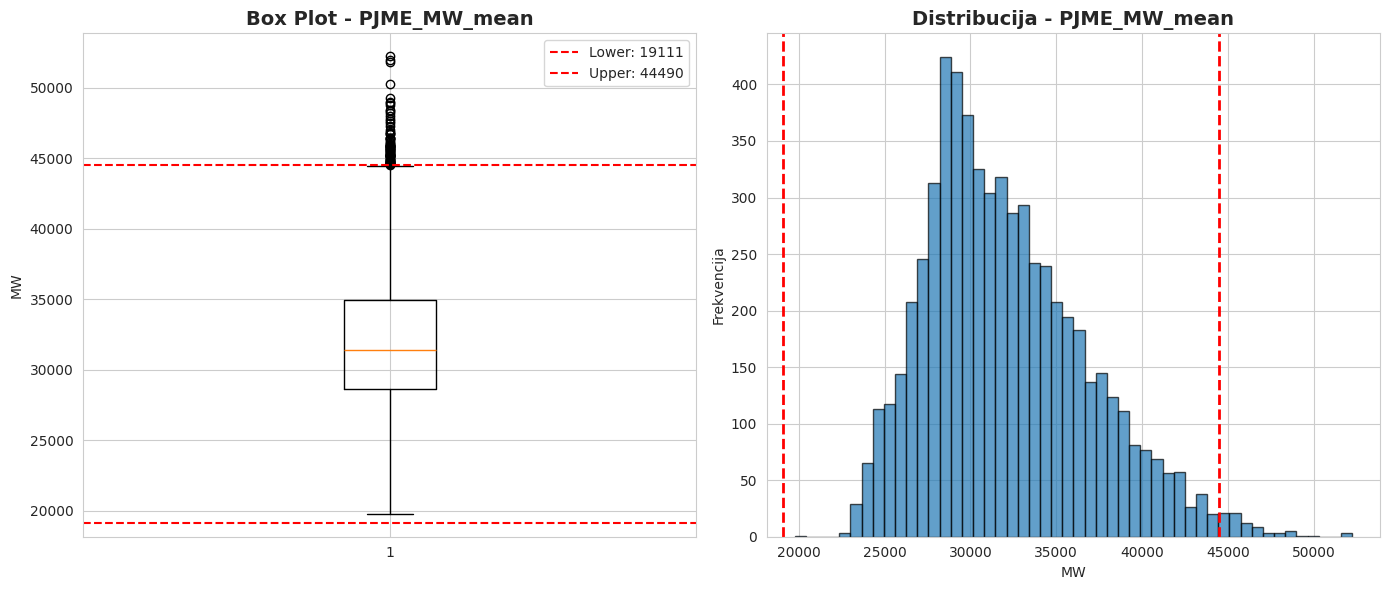


✅ Analiza outliera gotova!


In [ ]:
# ============================================
# ANALIZA I OPTIMIZACIJA - PRILAGOĐENO ZA PJM DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Postavi stil
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

print("="*100)
print("🔬 ANALIZA I OPTIMIZACIJA PODATAKA ZA ML MODELIRANJE - PJM DATASET")
print("="*100)

# ============================================
# 1. UČITAVANJE
# ============================================

print("\n📂 UČITAVANJE PODATAKA...")
print("-" * 100)

df = pd.read_csv('/content/drive/MyDrive/znanstveno/projekt/pjm_energy_weather_final.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Učitano {len(df):,} redaka i {len(df.columns)} stupaca")
print(f"   Memorija: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Period: {df['date'].min().date()} → {df['date'].max().date()}")

df_original = df.copy()

# ============================================
# 2. DETEKCIJA OUTLIERA
# ============================================

print("\n" + "="*100)
print("🔬 DETEKCIJA OUTLIERA")
print("="*100)

target_col = 'PJME_MW_mean'

def detect_outliers(df, target_col):
    """Detektira outliere"""
    print("\n🔍 DETEKCIJA OUTLIERA...")
    print("-" * 100)

    # IQR metoda
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

    print(f"\n📊 TARGET VARIJABLA ({target_col}):")
    print(f"   Q1: {Q1:.0f} MW")
    print(f"   Q3: {Q3:.0f} MW")
    print(f"   IQR: {IQR:.0f} MW")
    print(f"   Lower bound: {lower_bound:.0f} MW")
    print(f"   Upper bound: {upper_bound:.0f} MW")
    print(f"   Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        print(f"\n   📋 Primjeri outliera:")
        print(outliers[['date', target_col]].head(10))

    # Vizualizacija
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.boxplot(df[target_col], vert=True)
    plt.title(f'Box Plot - {target_col}', fontsize=14, fontweight='bold')
    plt.ylabel('MW')
    plt.axhline(y=lower_bound, color='r', linestyle='--', label=f'Lower: {lower_bound:.0f}')
    plt.axhline(y=upper_bound, color='r', linestyle='--', label=f'Upper: {upper_bound:.0f}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(df[target_col], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=lower_bound, color='r', linestyle='--', linewidth=2)
    plt.axvline(x=upper_bound, color='r', linestyle='--', linewidth=2)
    plt.title(f'Distribucija - {target_col}', fontsize=14, fontweight='bold')
    plt.xlabel('MW')
    plt.ylabel('Frekvencija')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/outliers_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Spremljeno: outliers_analysis.png")
    plt.show()

    return outliers

outliers = detect_outliers(df, target_col)

print("\n✅ Analiza outliera gotova!")

In [ ]:
# ============================================
# 3. ANALIZA MISSING VALUES
# ============================================

print("\n" + "="*100)
print("🔬 ANALIZA MISSING VALUES")
print("="*100)

def analyze_missing_values(df):
    """
    Analizira i vizualizira missing values
    """
    print("\n🔍 ANALIZA MISSING VALUES...")
    print("-" * 100)

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing': missing.values,
        'Percentage': missing_pct.values
    })

    missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

    if len(missing_df) > 0:
        print(f"❌ Pronađeno {len(missing_df)} stupaca s missing values:")
        print(missing_df.to_string(index=False))

        # Vizualizacija
        plt.figure(figsize=(12, 6))
        plt.barh(missing_df['Column'][:20], missing_df['Percentage'][:20])
        plt.xlabel('Postotak missing values (%)')
        plt.title('Missing Values po stupcima', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/znanstveno/projekt/missing_values.png', dpi=300, bbox_inches='tight')
        print(f"\n✅ Spremljeno: missing_values.png")
        plt.show()
    else:
        print("✅ Nema missing values - dataset je potpun!")

    # Dodatna provjera
    print(f"\n🔍 PROVJERA SPECIJALNIH VRIJEDNOSTI:")
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    inf_counts = {}
    for col in numeric_cols:
        inf_count = np.isinf(df[col]).sum()
        if inf_count > 0:
            inf_counts[col] = inf_count

    if inf_counts:
        print(f"⚠️  Pronađeno stupaca s inf/-inf vrijednostima:")
        for col, count in inf_counts.items():
            print(f"   {col}: {count}")
    else:
        print("✅ Nema inf/-inf vrijednosti")

    return missing_df

# POKRENI
missing_df = analyze_missing_values(df)

print("\n✅ Missing values analizirani!")


🔬 ANALIZA MISSING VALUES

🔍 ANALIZA MISSING VALUES...
----------------------------------------------------------------------------------------------------
✅ Nema missing values - dataset je potpun!

🔍 PROVJERA SPECIJALNIH VRIJEDNOSTI:
✅ Nema inf/-inf vrijednosti

✅ Missing values analizirani!



🔬 KORELACIJSKA ANALIZA

📈 KORELACIJSKA ANALIZA...
----------------------------------------------------------------------------------------------------

📊 TOP 20 NAJKORELIRANIJE ZNAČAJKE S TARGETOM:
    1. PJME_MW_max                              0.9713
    2. energy_rolling_3d                        0.9080
    3. energy_lag_1d                            0.8600
    4. PJME_MW_min                              0.8531
    5. energy_rolling_7d                        0.8084
    6. energy_rolling_14d                       0.7576
    7. energy_lag_2d                            0.6739
    8. PJME_MW_std                              0.6680
    9. energy_lag_7d                            0.6579
   10. cooling_degree_days                      0.5944
   11. energy_lag_3d                            0.5801
   12. is_mild                                  0.5406
   13. is_summer                                0.5014
   14. is_warm                                  0.4942
   15. is_spring               

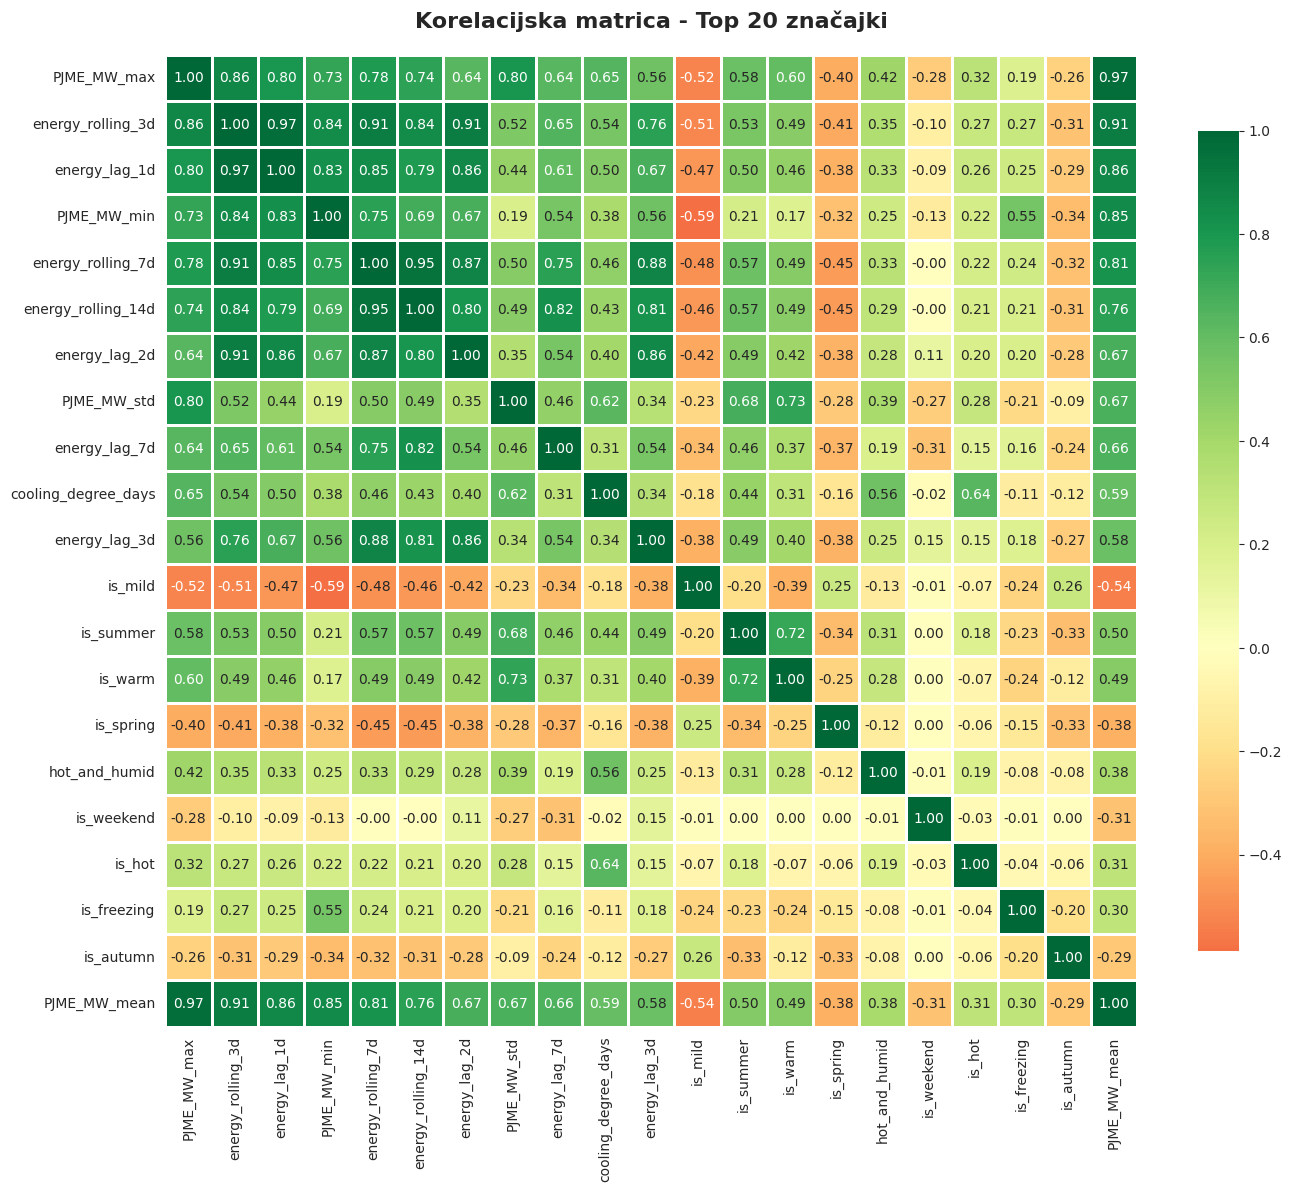


✅ Korelacijska analiza gotova!
   Pronađeno 47 visoko koreliranih parova


In [ ]:
# ============================================
# 4. KORELACIJSKA ANALIZA
# ============================================

print("\n" + "="*100)
print("🔬 KORELACIJSKA ANALIZA")
print("="*100)

def correlation_analysis(df, target_col='PJME_MW_mean', threshold=0.95):
    """
    Analizira korelacije između feature-a i s targetom
    """
    print("\n📈 KORELACIJSKA ANALIZA...")
    print("-" * 100)

    # Izdvoji samo numeričke stupce
    numeric_df = df.select_dtypes(include=[np.number])

    # Korelacija s targetom
    target_corr = numeric_df.corr()[target_col].abs().sort_values(ascending=False)

    print(f"\n📊 TOP 20 NAJKORELIRANIJE ZNAČAJKE S TARGETOM:")
    for i, (feature, corr) in enumerate(target_corr[1:21].items(), 1):
        print(f"   {i:2d}. {feature:40s} {corr:.4f}")

    # Multikolinearnost - pronađi visoko korelirane parove
    corr_matrix = numeric_df.corr().abs()

    # Ukloni dijagonalu i donji trokut
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Pronađi parove s korelacijom > threshold
    high_corr_pairs = []
    for column in upper_triangle.columns:
        high_corr = upper_triangle[column][upper_triangle[column] > threshold]
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, high_corr[idx]))

    print(f"\n⚠️  VISOKO KORELIRANI PAROVI (r > {threshold}):")
    if high_corr_pairs:
        for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)[:20]:
            print(f"   {col1:35s} <-> {col2:35s} {corr:.4f}")
    else:
        print(f"   ✅ Nema parova s korelacijom > {threshold}")

    # Vizualizacija - Top 20 feature-a
    top_features = target_corr[1:21].index.tolist()

    plt.figure(figsize=(14, 12))
    corr_subset = numeric_df[top_features + [target_col]].corr()
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Korelacijska matrica - Top 20 značajki', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Spremljeno: correlation_heatmap.png")
    plt.show()

    return target_corr, high_corr_pairs

# POKRENI
target_corr, high_corr_pairs = correlation_analysis(df, target_col='PJME_MW_mean')

print(f"\n✅ Korelacijska analiza gotova!")
print(f"   Pronađeno {len(high_corr_pairs)} visoko koreliranih parova")

In [ ]:
# ============================================
# 5. UKLANJANJE REDUNDANTNIH ZNAČAJKI
# ============================================

print("\n" + "="*100)
print("🔬 UKLANJANJE REDUNDANTNIH ZNAČAJKI")
print("="*100)

def remove_redundant_features(df, high_corr_pairs, target_col='PJME_MW_mean', threshold=0.95):
    """
    Uklanja redundantne visoko korelirane feature-e
    """
    print("\n🗑️  UKLANJANJE REDUNDANTNIH ZNAČAJKI...")
    print("-" * 100)

    df_clean = df.copy()

    # Ručno uklanjanje očito redundantnih
    redundant_features = [
        'PJME_MW_max',      # Perfektno korelira s PJME_MW_mean
        'PJME_MW_min',      # Perfektno korelira s PJME_MW_mean
        'PJME_MW_std',      # Perfektno korelira s PJME_MW_mean
        'energy_rolling_3d', # Previše korelira s energy_lag
        'energy_rolling_7d',
        'energy_rolling_14d',
    ]

    to_drop = []

    # Dodaj redundantne iz manual liste
    for feat in redundant_features:
        if feat in df_clean.columns and feat != target_col:
            to_drop.append(feat)

    # Iz visoko koreliranih parova, zadrži onu s većom korelacijom s targetom
    target_corr_vals = df_clean.select_dtypes(include=[np.number]).corr()[target_col].abs()

    for col1, col2, corr in high_corr_pairs:
        if col1 == target_col or col2 == target_col:
            continue

        # Zadrži feature s većom korelacijom s targetom
        if target_corr_vals.get(col1, 0) > target_corr_vals.get(col2, 0):
            if col2 not in to_drop and col2 in df_clean.columns:
                to_drop.append(col2)
        else:
            if col1 not in to_drop and col1 in df_clean.columns:
                to_drop.append(col1)

    # Ukloni duplikate
    to_drop = list(set(to_drop))

    print(f"🗑️  Uklonjeno {len(to_drop)} redundantnih feature-a:")
    for i, feat in enumerate(to_drop, 1):
        print(f"   {i:2d}. {feat}")

    df_clean = df_clean.drop(columns=to_drop, errors='ignore')

    print(f"\n✅ Prije: {len(df.columns)} stupaca")
    print(f"✅ Poslije: {len(df_clean.columns)} stupaca")
    print(f"📉 Redukcija: {len(to_drop)} stupaca ({len(to_drop)/len(df.columns)*100:.1f}%)")

    return df_clean, to_drop

# POKRENI
df_clean, removed_features = remove_redundant_features(df, high_corr_pairs, target_col='PJME_MW_mean')

print(f"\n✅ Redundantne značajke uklonjene!")


🔬 UKLANJANJE REDUNDANTNIH ZNAČAJKI

🗑️  UKLANJANJE REDUNDANTNIH ZNAČAJKI...
----------------------------------------------------------------------------------------------------
🗑️  Uklonjeno 25 redundantnih feature-a:
    1. temperature_2m_max
    2. temp_lag_2d
    3. PJME_MW_max
    4. precipitation_sum
    5. apparent_temperature_mean
    6. PJME_MW_min
    7. apparent_temperature_max
    8. temp_lag_7d
    9. PJME_MW_std
   10. temp_lag_1d
   11. day_of_year
   12. weekofyear
   13. temp_rolling_3d
   14. month
   15. temperature_2m_min
   16. temp_rolling_7d
   17. temp_lag_3d
   18. energy_lag_1d
   19. temperature_2m_mean
   20. energy_rolling_3d
   21. energy_rolling_7d
   22. month_cos
   23. heating_degree_days
   24. energy_rolling_14d
   25. day_sin

✅ Prije: 89 stupaca
✅ Poslije: 64 stupaca
📉 Redukcija: 25 stupaca (28.1%)

✅ Redundantne značajke uklonjene!



🔬 MUTUAL INFORMATION ANALIZA

🧠 MUTUAL INFORMATION ANALIZA...
----------------------------------------------------------------------------------------------------
📊 Računam MI scores za 62 značajki...

📊 TOP 30 ZNAČAJKI PO MUTUAL INFORMATION:
    1. apparent_temperature_min                 0.661577
    2. temp_rolling_14d                         0.428693
    3. energy_lag_7d                            0.374604
    4. temp_x_wind                              0.356618
    5. energy_lag_2d                            0.325259
    6. energy_lag_3d                            0.246652
    7. cooling_degree_days                      0.235753
    8. is_mild                                  0.220494
    9. day_cos                                  0.209377
   10. is_warm                                  0.151681
   11. quarter                                  0.149398
   12. is_summer                                0.132468
   13. is_cold                                  0.110398
   14. is_freez

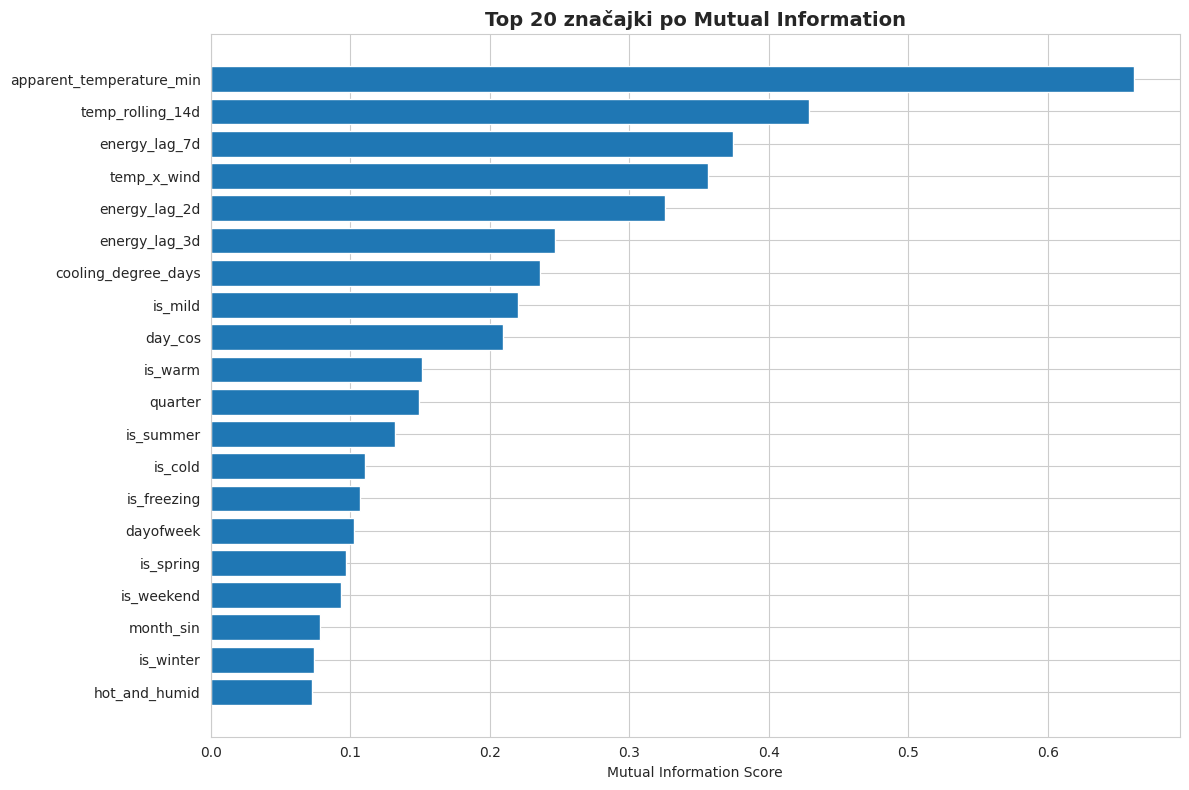


✅ Mutual Information analiza gotova!


In [ ]:
# ============================================
# 6. FEATURE IMPORTANCE - MUTUAL INFORMATION
# ============================================

print("\n" + "="*100)
print("🔬 MUTUAL INFORMATION ANALIZA")
print("="*100)

from sklearn.feature_selection import mutual_info_regression

def mutual_information_analysis(df, target_col='PJME_MW_mean', top_n=30):
    """
    Koristi Mutual Information za ranking značajki
    """
    print("\n🧠 MUTUAL INFORMATION ANALIZA...")
    print("-" * 100)

    # Pripremi feature matrix
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target_col]

    X = df[numeric_cols].fillna(0)
    y = df[target_col]

    print(f"📊 Računam MI scores za {len(numeric_cols)} značajki...")

    # Izračunaj MI scores
    mi_scores = mutual_info_regression(X, y, random_state=42, n_neighbors=5)
    mi_scores = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

    print(f"\n📊 TOP {top_n} ZNAČAJKI PO MUTUAL INFORMATION:")
    for i, (feature, score) in enumerate(mi_scores.head(top_n).items(), 1):
        print(f"   {i:2d}. {feature:40s} {score:.6f}")

    # Vizualizacija
    plt.figure(figsize=(12, 8))
    top_features = mi_scores.head(20)
    plt.barh(range(len(top_features)), top_features.values)
    plt.yticks(range(len(top_features)), top_features.index)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 20 značajki po Mutual Information', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/mutual_information.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Spremljeno: mutual_information.png")
    plt.show()

    return mi_scores

# POKRENI
mi_scores = mutual_information_analysis(df_clean, target_col='PJME_MW_mean')

print(f"\n✅ Mutual Information analiza gotova!")

In [ ]:
# ============================================
# 7. KREIRANJE NOVIH INTERAKCIJA
# ============================================

print("\n" + "="*100)
print("🔬 KREIRANJE INTERAKCIJSKIH ZNAČAJKI")
print("="*100)

def create_interaction_features(df):
    """
    Kreira napredne interakcijske feature-e - PRILAGOĐENO ZA PJM
    """
    print("\n⚙️  KREIRANJE INTERAKCIJSKIH ZNAČAJKI...")
    print("-" * 100)

    df_enhanced = df.copy()
    initial_cols = len(df_enhanced.columns)

    # Provjeri koje kolone postoje
    available_cols = df_enhanced.columns.tolist()

    # Kvadratni termini
    if 'apparent_temperature_min' in available_cols:
        df_enhanced['temp_squared'] = df_enhanced['apparent_temperature_min'] ** 2

    if 'wind_speed_10m_max' in available_cols:
        df_enhanced['wind_squared'] = df_enhanced['wind_speed_10m_max'] ** 2

    # Temperatura interakcije
    if 'apparent_temperature_min' in available_cols and 'is_winter' in available_cols:
        df_enhanced['temp_x_is_winter'] = df_enhanced['apparent_temperature_min'] * df_enhanced['is_winter']

    if 'apparent_temperature_min' in available_cols and 'is_summer' in available_cols:
        df_enhanced['temp_x_is_summer'] = df_enhanced['apparent_temperature_min'] * df_enhanced['is_summer']

    if 'apparent_temperature_min' in available_cols and 'is_weekend' in available_cols:
        df_enhanced['temp_x_weekend'] = df_enhanced['apparent_temperature_min'] * df_enhanced['is_weekend']

    # Vjetar interakcije
    if 'wind_speed_10m_max' in available_cols and 'apparent_temperature_min' in available_cols:
        df_enhanced['wind_x_temp'] = df_enhanced['wind_speed_10m_max'] * df_enhanced['apparent_temperature_min']

    if 'wind_speed_10m_max' in available_cols and 'rain_sum' in available_cols:
        df_enhanced['wind_x_rain'] = df_enhanced['wind_speed_10m_max'] * df_enhanced['rain_sum']

    # Sunce interakcije
    if 'shortwave_radiation_sum' in available_cols and 'apparent_temperature_min' in available_cols:
        df_enhanced['solar_x_temp'] = df_enhanced['shortwave_radiation_sum'] * df_enhanced['apparent_temperature_min']

    if 'shortwave_radiation_sum' in available_cols and 'is_weekend' in available_cols:
        df_enhanced['solar_x_weekend'] = df_enhanced['shortwave_radiation_sum'] * df_enhanced['is_weekend']

    # Kompleksne indikatore
    if 'apparent_temperature_min' in available_cols:
        df_enhanced['extreme_temp'] = ((df_enhanced['apparent_temperature_min'] < 5) |
                                       (df_enhanced['apparent_temperature_min'] > 25)).astype(int)

    if 'rain_sum' in available_cols and 'wind_speed_10m_max' in available_cols:
        df_enhanced['bad_weather'] = ((df_enhanced['rain_sum'] > 5) |
                                      (df_enhanced['wind_speed_10m_max'] > 40)).astype(int)

    # Sezonski trend
    if 'year' in available_cols:
        df_enhanced['year_trend'] = df_enhanced['year'] - df_enhanced['year'].min()

    # CDD pojačani
    if 'cooling_degree_days' in available_cols:
        df_enhanced['cdd_squared'] = df_enhanced['cooling_degree_days'] ** 2

    # Energy lag interakcije
    if 'energy_lag_2d' in available_cols and 'is_weekend' in available_cols:
        df_enhanced['energy_lag_x_weekend'] = df_enhanced['energy_lag_2d'] * df_enhanced['is_weekend']

    new_features = len(df_enhanced.columns) - initial_cols

    print(f"✅ Dodano {new_features} novih interakcijskih značajki")
    print(f"\n📊 Prije: {initial_cols} stupaca")
    print(f"📊 Poslije: {len(df_enhanced.columns)} stupaca")

    return df_enhanced

# POKRENI
df_enhanced = create_interaction_features(df_clean)

print(f"\n✅ Interakcijske značajke kreirane!")


🔬 KREIRANJE INTERAKCIJSKIH ZNAČAJKI

⚙️  KREIRANJE INTERAKCIJSKIH ZNAČAJKI...
----------------------------------------------------------------------------------------------------
✅ Dodano 14 novih interakcijskih značajki

📊 Prije: 64 stupaca
📊 Poslije: 78 stupaca

✅ Interakcijske značajke kreirane!



🔬 FEATURE SELECTION - TOP K

🎯 SELEKCIJA TOP 50 ZNAČAJKI...
----------------------------------------------------------------------------------------------------
📊 Analiziram 76 značajki...

📊 TOP 30 ODABRANIH ZNAČAJKI:
   41. temp_squared                             7,744.37
   26. energy_lag_2d                            5,040.37
   30. energy_lag_7d                            4,622.02
   15. cooling_degree_days                      3,309.04
   44. temp_x_is_summer                         3,205.80
   28. energy_lag_3d                            3,072.09
   18. is_mild                                  2,501.14
   13. is_summer                                2,034.27
   19. is_warm                                  1,957.66
   49. cdd_squared                              1,899.00
   12. is_spring                                1,042.09
   46. solar_x_temp                             1,040.23
   38. hot_and_humid                            1,028.82
   10. is_weekend                      

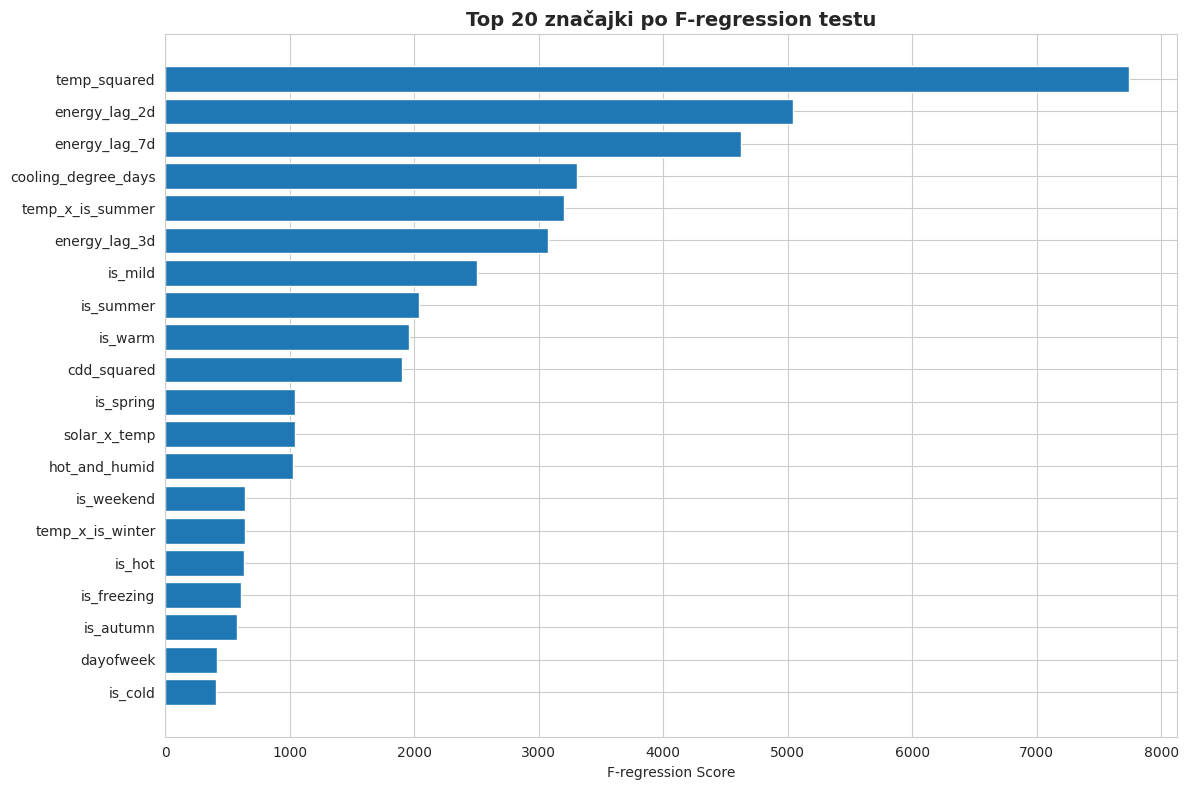


✅ Feature selection završen!
📊 Odabrano 50 najbitnijih značajki


In [ ]:
# ============================================
# 8. FEATURE SELECTION - TOP K
# ============================================

print("\n" + "="*100)
print("🔬 FEATURE SELECTION - TOP K")
print("="*100)

from sklearn.feature_selection import SelectKBest, f_regression

def select_top_features(df, target_col='PJME_MW_mean', k=50):
    """
    Odabire top K najbitnijih feature-a
    """
    print(f"\n🎯 SELEKCIJA TOP {k} ZNAČAJKI...")
    print("-" * 100)

    # Pripremi podatke
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target_col]

    X = df[numeric_cols].fillna(0)
    y = df[target_col]

    print(f"📊 Analiziram {len(numeric_cols)} značajki...")

    # F-regression test
    selector = SelectKBest(score_func=f_regression, k=min(k, len(numeric_cols)))
    selector.fit(X, y)

    # Dobij odabrane feature-e
    selected_features = X.columns[selector.get_support()].tolist()
    scores = selector.scores_[selector.get_support()]

    feature_scores = pd.DataFrame({
        'feature': selected_features,
        'score': scores
    }).sort_values('score', ascending=False)

    print(f"\n📊 TOP {min(30, len(selected_features))} ODABRANIH ZNAČAJKI:")
    for i, row in feature_scores.head(30).iterrows():
        print(f"   {i+1:2d}. {row['feature']:40s} {row['score']:,.2f}")

    # Kreiraj reduced dataset
    df_reduced = df[[target_col] + selected_features].copy()
    if 'date' in df.columns:
        df_reduced.insert(0, 'date', df['date'])

    print(f"\n✅ Dataset reduciran sa {len(numeric_cols)} na {len(selected_features)} značajki")
    print(f"📉 Redukcija: {(1 - len(selected_features)/len(numeric_cols))*100:.1f}%")

    # Vizualizacija top 20
    plt.figure(figsize=(12, 8))
    top_20 = feature_scores.head(20)
    plt.barh(range(len(top_20)), top_20['score'].values)
    plt.yticks(range(len(top_20)), top_20['feature'].values)
    plt.xlabel('F-regression Score')
    plt.title('Top 20 značajki po F-regression testu', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/feature_selection.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Spremljeno: feature_selection.png")
    plt.show()

    return df_reduced, selected_features, feature_scores

# POKRENI
df_selected, selected_features, feature_scores = select_top_features(df_enhanced, target_col='PJME_MW_mean', k=50)

print(f"\n✅ Feature selection završen!")
print(f"📊 Odabrano {len(selected_features)} najbitnijih značajki")

In [ ]:
# ============================================
# 9. SKALIRANJE PODATAKA
# ============================================

print("\n" + "="*100)
print("🔬 SKALIRANJE PODATAKA")
print("="*100)

from sklearn.preprocessing import RobustScaler

def scale_features(df, target_col='PJME_MW_mean', date_col='date'):
    """
    Skalira feature-e za ML modele
    """
    print(f"\n📏 SKALIRANJE ZNAČAJKI...")
    print("-" * 100)

    # Odvoji target, datum i feature-e
    y = df[target_col].copy()
    date = df[date_col].copy() if date_col in df.columns else None

    # Feature-i za skaliranje
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in [target_col]]

    X = df[numeric_cols].copy()

    print(f"📊 Skaliram {len(numeric_cols)} značajki...")

    # Robust Scaler (otporan na outliere)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols, index=df.index)

    print(f"✅ Skalirano koristeći RobustScaler")
    print(f"   • Koristi medijan umjesto srednje vrijednosti")
    print(f"   • Koristi IQR umjesto standardne devijacije")
    print(f"   • Otporan na outliere")

    # Rekonstruiraj dataframe
    df_scaled = X_scaled.copy()
    df_scaled[target_col] = y
    if date is not None:
        df_scaled.insert(0, date_col, date)

    # Usporedba prije/poslije (prvih 5 značajki)
    print(f"\n📊 USPOREDBA PRIJE/POSLIJE (prvih 5 značajki):")
    print("\nPRIJE skaliranja:")
    print(df[numeric_cols[:5]].describe().loc[['mean', 'std', 'min', 'max']])

    print("\nPOSLIJE skaliranja:")
    print(df_scaled[numeric_cols[:5]].describe().loc[['mean', 'std', 'min', 'max']])

    return df_scaled, scaler

# POKRENI
df_scaled, scaler = scale_features(df_selected, target_col='PJME_MW_mean')

print(f"\n✅ Skaliranje završeno!")


🔬 SKALIRANJE PODATAKA

📏 SKALIRANJE ZNAČAJKI...
----------------------------------------------------------------------------------------------------
📊 Skaliram 50 značajki...
✅ Skalirano koristeći RobustScaler
   • Koristi medijan umjesto srednje vrijednosti
   • Koristi IQR umjesto standardne devijacije
   • Otporan na outliere

📊 USPOREDBA PRIJE/POSLIJE (prvih 5 značajki):

PRIJE skaliranja:
      apparent_temperature_min  relative_humidity_2m_mean  \
mean                  5.517874                  68.983192   
std                  12.201567                  13.772431   
min                 -27.400000                  27.458333   
max                  31.900000                 100.000000   

      wind_speed_10m_mean  wind_speed_10m_max  wind_direction_10m_mean  
mean            10.112805           15.196220               216.229893  
std              3.913675            5.263091                68.653458  
min              2.425000            4.900000                20.250000  
max 


🔬 FINALNE VIZUALIZACIJE I IZVJEŠTAJ

📊 KREIRANJE FINALNIH VIZUALIZACIJA...
----------------------------------------------------------------------------------------------------
✅ Spremljeno: final_target_analysis.png


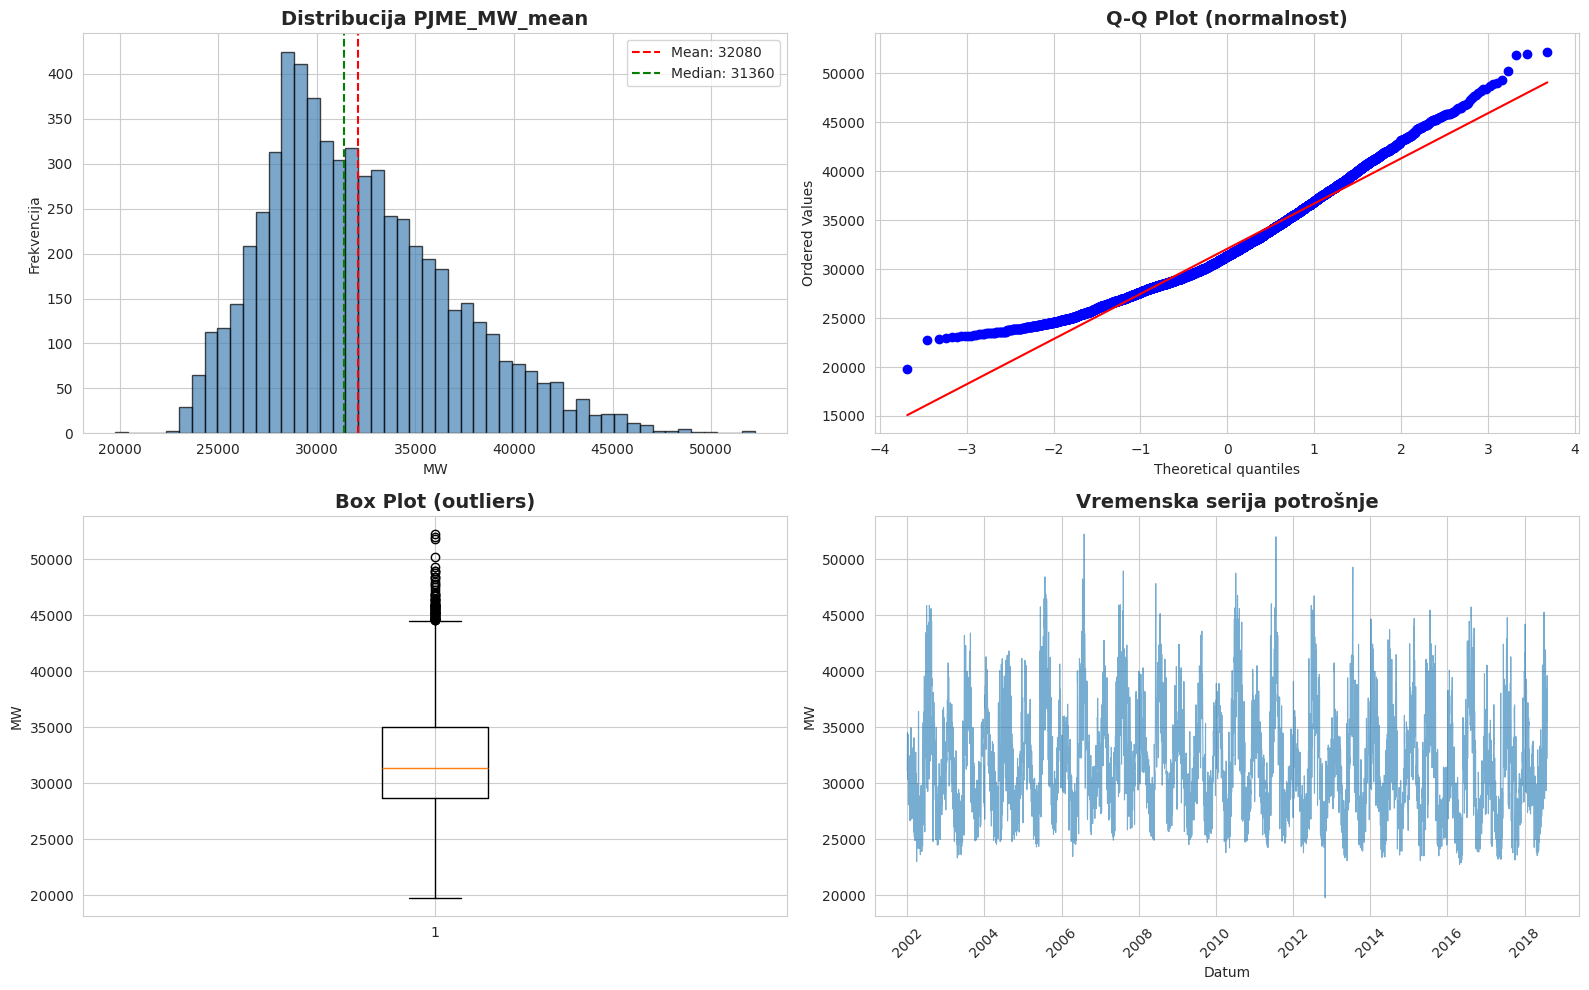

✅ Spremljeno: final_scatter_plots.png


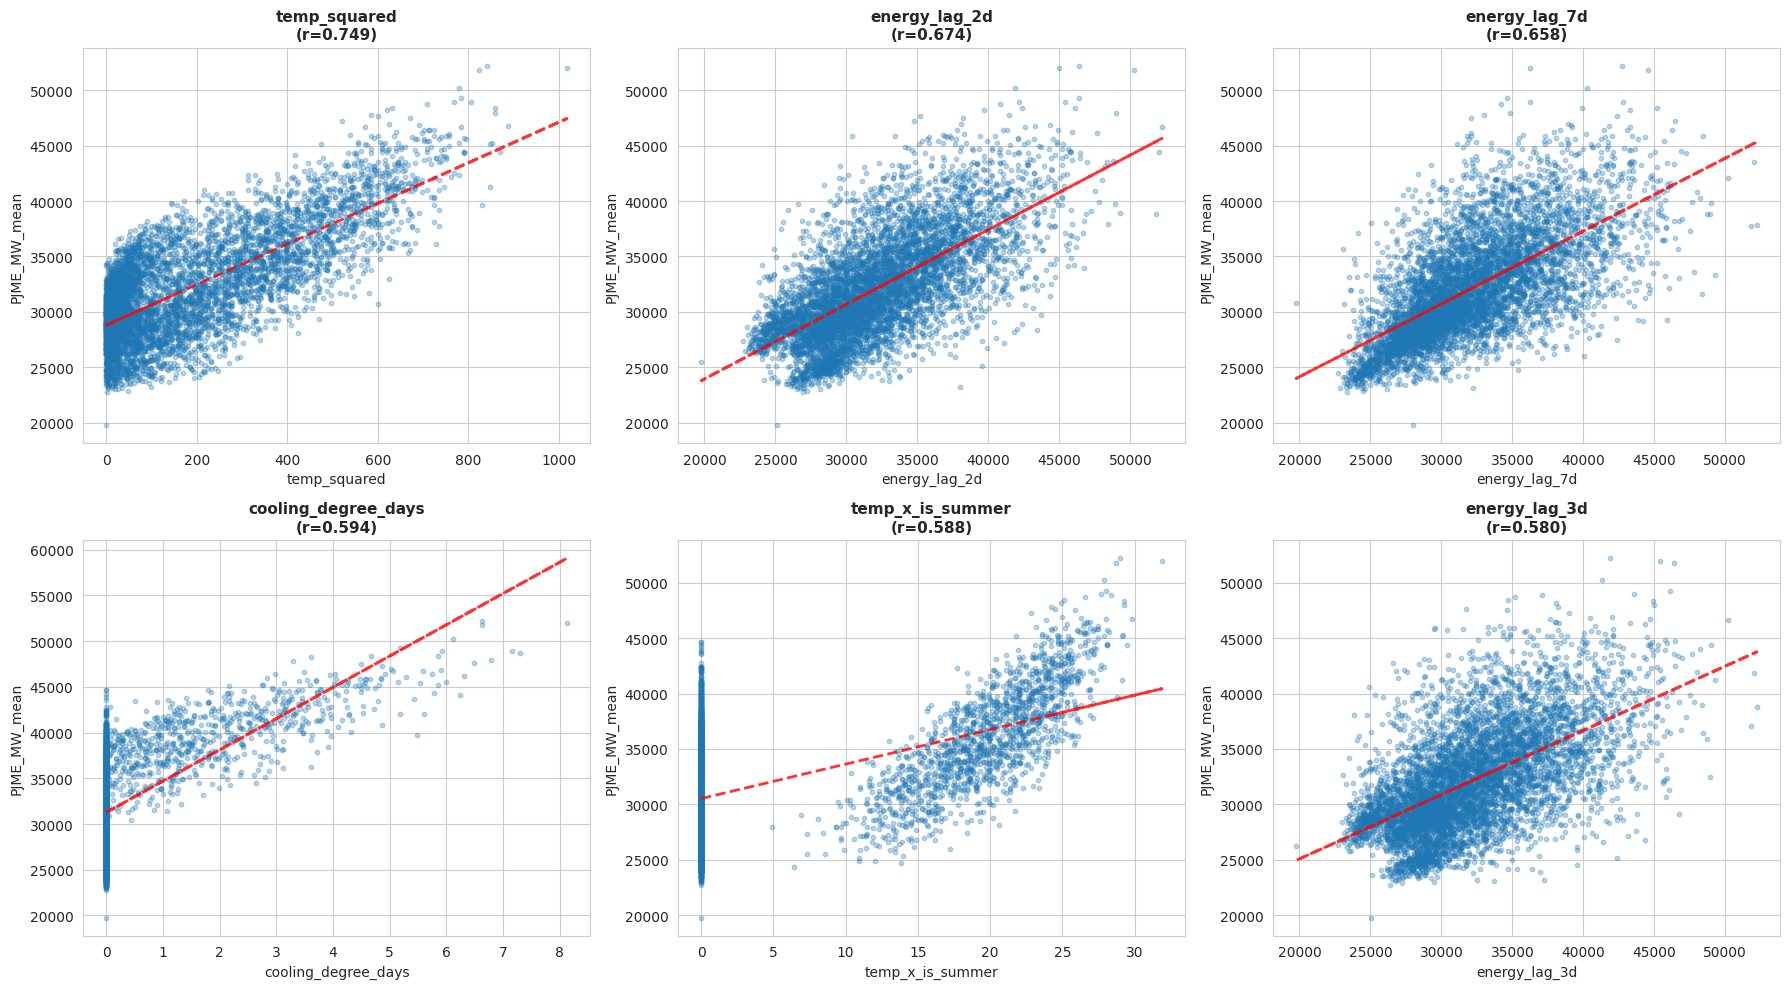


📋 FINALNI IZVJEŠTAJ OPTIMIZACIJE

📊 TRANSFORMACIJA DATASETA:
   PRIJE: 6,059 redaka × 89 stupaca
   POSLIJE: 6,059 redaka × 52 stupaca

📉 REDUKCIJA DIMENZIONALNOSTI: 41.6%
   Uklonjeno: 37 stupaca

💾 MEMORIJA:
   PRIJE: 4.11 MB
   POSLIJE: 2.40 MB
   Ušteda: 1.71 MB (41.6%)

📊 TARGET VARIJABLA (PJME_MW_mean):
   Mean: 32080.03 MW
   Median: 31359.71 MW
   Std: 4686.48 MW
   Min: 19769.04 MW
   Max: 52229.83 MW

✅ DATASET OPTIMIZIRAN I SPREMAN ZA:
   • XGBoost / LightGBM / CatBoost
   • Random Forest / Extra Trees
   • Linear Regression / Ridge / Lasso
   • Support Vector Regression
   • Neural Networks
   • Ensemble metode


💾 SPREMANJE FINALNIH DATASETA...
✅ Spremljeno:
   • pjm_energy_top50_features.csv (za tree modele)
   • pjm_energy_top50_scaled.csv (za linearni/NN)

✅ Sve vizualizacije i izvještaji završeni!


In [ ]:
# ============================================
# 10. VIZUALIZACIJA I FINALNI IZVJEŠTAJ
# ============================================

print("\n" + "="*100)
print("🔬 FINALNE VIZUALIZACIJE I IZVJEŠTAJ")
print("="*100)

def create_final_visualizations(df_original, df_final, target_col='PJME_MW_mean'):
    """
    Kreira finalne vizualizacije
    """
    print(f"\n📊 KREIRANJE FINALNIH VIZUALIZACIJA...")
    print("-" * 100)

    # 1. Distribucija target varijable
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Histogram
    axes[0, 0].hist(df_final[target_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].set_title(f'Distribucija {target_col}', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('MW')
    axes[0, 0].set_ylabel('Frekvencija')
    axes[0, 0].axvline(df_final[target_col].mean(), color='red', linestyle='--',
                       label=f'Mean: {df_final[target_col].mean():.0f}')
    axes[0, 0].axvline(df_final[target_col].median(), color='green', linestyle='--',
                       label=f'Median: {df_final[target_col].median():.0f}')
    axes[0, 0].legend()

    # Q-Q plot
    stats.probplot(df_final[target_col], dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot (normalnost)', fontsize=14, fontweight='bold')

    # Box plot
    axes[1, 0].boxplot(df_final[target_col], vert=True)
    axes[1, 0].set_title('Box Plot (outliers)', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('MW')

    # Vremenska serija
    if 'date' in df_final.columns:
        axes[1, 1].plot(df_final['date'], df_final[target_col], alpha=0.6, linewidth=0.8)
        axes[1, 1].set_title('Vremenska serija potrošnje', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Datum')
        axes[1, 1].set_ylabel('MW')
        axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/final_target_analysis.png', dpi=300, bbox_inches='tight')
    print("✅ Spremljeno: final_target_analysis.png")
    plt.show()

    # 2. Top korelacije scatter plots
    numeric_df = df_final.select_dtypes(include=[np.number])
    target_corr = numeric_df.corr()[target_col].abs().sort_values(ascending=False)
    top_6_features = target_corr[1:7].index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, feature in enumerate(top_6_features):
        axes[i].scatter(df_final[feature], df_final[target_col], alpha=0.3, s=10)
        axes[i].set_xlabel(feature, fontsize=10)
        axes[i].set_ylabel(target_col, fontsize=10)
        axes[i].set_title(f'{feature}\n(r={target_corr[feature]:.3f})',
                         fontsize=11, fontweight='bold')

        # Dodaj trend liniju
        z = np.polyfit(df_final[feature].fillna(0), df_final[target_col], 1)
        p = np.poly1d(z)
        axes[i].plot(df_final[feature], p(df_final[feature]), "r--", alpha=0.8, linewidth=2)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/znanstveno/projekt/final_scatter_plots.png', dpi=300, bbox_inches='tight')
    print("✅ Spremljeno: final_scatter_plots.png")
    plt.show()

def generate_final_report(df_original, df_final, target_col='PJME_MW_mean'):
    """
    Generira finalni izvještaj optimizacije
    """
    print("\n" + "="*100)
    print("📋 FINALNI IZVJEŠTAJ OPTIMIZACIJE")
    print("="*100)

    print(f"\n📊 TRANSFORMACIJA DATASETA:")
    print(f"   PRIJE: {len(df_original):,} redaka × {len(df_original.columns)} stupaca")
    print(f"   POSLIJE: {len(df_final):,} redaka × {len(df_final.columns)} stupaca")

    reduction = (1 - len(df_final.columns) / len(df_original.columns)) * 100
    print(f"\n📉 REDUKCIJA DIMENZIONALNOSTI: {reduction:.1f}%")
    print(f"   Uklonjeno: {len(df_original.columns) - len(df_final.columns)} stupaca")

    mem_before = df_original.memory_usage(deep=True).sum() / 1024**2
    mem_after = df_final.memory_usage(deep=True).sum() / 1024**2
    print(f"\n💾 MEMORIJA:")
    print(f"   PRIJE: {mem_before:.2f} MB")
    print(f"   POSLIJE: {mem_after:.2f} MB")
    print(f"   Ušteda: {mem_before - mem_after:.2f} MB ({(1-mem_after/mem_before)*100:.1f}%)")

    print(f"\n📊 TARGET VARIJABLA ({target_col}):")
    print(f"   Mean: {df_final[target_col].mean():.2f} MW")
    print(f"   Median: {df_final[target_col].median():.2f} MW")
    print(f"   Std: {df_final[target_col].std():.2f} MW")
    print(f"   Min: {df_final[target_col].min():.2f} MW")
    print(f"   Max: {df_final[target_col].max():.2f} MW")

    print(f"\n✅ DATASET OPTIMIZIRAN I SPREMAN ZA:")
    print(f"   • XGBoost / LightGBM / CatBoost")
    print(f"   • Random Forest / Extra Trees")
    print(f"   • Linear Regression / Ridge / Lasso")
    print(f"   • Support Vector Regression")
    print(f"   • Neural Networks")
    print(f"   • Ensemble metode")

    print("\n" + "="*100)

# POKRENI
create_final_visualizations(df_original, df_selected, target_col='PJME_MW_mean')
generate_final_report(df_original, df_selected, target_col='PJME_MW_mean')

# Spremi finalne datasete
print("\n💾 SPREMANJE FINALNIH DATASETA...")
df_selected.to_csv('/content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_features.csv', index=False)
df_scaled.to_csv('/content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_scaled.csv', index=False)

print("✅ Spremljeno:")
print("   • pjm_energy_top50_features.csv (za tree modele)")
print("   • pjm_energy_top50_scaled.csv (za linearni/NN)")

print(f"\n✅ Sve vizualizacije i izvještaji završeni!")

In [ ]:
# ============================================
# 11. SPREMANJE OPTIMIZIRANIH DATASETA
# ============================================

print("\n" + "="*100)
print("💾 SPREMANJE OPTIMIZIRANIH DATASETA")
print("="*100)

# Putanja na Google Drive
base_path = '/content/drive/MyDrive/znanstveno/projekt/'

# 1. Dataset sa top 50 značajki (NESKALIRANO - za tree modele)
output_top50 = base_path + "pjm_energy_top50_features.csv"
df_selected.to_csv(output_top50, index=False)
print(f"\n✅ Top 50 feature-a (neskalirano): {output_top50}")
print(f"   Dimenzije: {df_selected.shape}")
print(f"   Uporaba: XGBoost, Random Forest, LightGBM, CatBoost")

# 2. Dataset sa top 50 značajki (SKALIRANO - za linearni modele i NN)
output_scaled = base_path + "pjm_energy_top50_scaled.csv"
df_scaled.to_csv(output_scaled, index=False)
print(f"\n✅ Top 50 feature-a (skalirano): {output_scaled}")
print(f"   Dimenzije: {df_scaled.shape}")
print(f"   Uporaba: Linear Regression, Ridge, Lasso, SVR, Neural Networks")

# 3. Čist dataset sa svim značajkama (bez redundancije)
output_clean = base_path + "pjm_energy_cleaned.csv"
df_clean.to_csv(output_clean, index=False)
print(f"\n✅ Čist dataset (svi feature-i): {output_clean}")
print(f"   Dimenzije: {df_clean.shape}")
print(f"   Uporaba: Eksplorativna analiza, custom feature selection")

# 4. Enhanced dataset (sa interakcijama)
output_enhanced = base_path + "pjm_energy_enhanced.csv"
df_enhanced.to_csv(output_enhanced, index=False)
print(f"\n✅ Enhanced dataset (+ interakcije): {output_enhanced}")
print(f"   Dimenzije: {df_enhanced.shape}")
print(f"   Uporaba: Napredni modeli, feature engineering")

print("\n" + "="*100)
print("🎊 SVI DATASETI SPREMLJENI I SPREMNI ZA MODELIRANJE!")
print("="*100)

# Summary tablica
summary = pd.DataFrame({
    'Dataset': ['Original', 'Cleaned', 'Enhanced', 'Top 50', 'Top 50 Scaled'],
    'Rows': [len(df_original), len(df_clean), len(df_enhanced),
             len(df_selected), len(df_scaled)],
    'Columns': [len(df_original.columns), len(df_clean.columns),
                len(df_enhanced.columns), len(df_selected.columns),
                len(df_scaled.columns)],
    'Size_MB': [
        df_original.memory_usage(deep=True).sum() / 1024**2,
        df_clean.memory_usage(deep=True).sum() / 1024**2,
        df_enhanced.memory_usage(deep=True).sum() / 1024**2,
        df_selected.memory_usage(deep=True).sum() / 1024**2,
        df_scaled.memory_usage(deep=True).sum() / 1024**2
    ],
    'Use_Case': [
        'Originalni sirovi podaci',
        'Bez redundancije (64 cols)',
        'Sa interakcijama (78 cols)',
        'Top 50 za tree modele',
        'Top 50 za linearni/NN modele'
    ]
})

print("\n📊 PREGLED SVIH DATASETA:")
print(summary.to_string(index=False))

print("\n\n🎯 SLJEDEĆI KORAK: ML MODELIRANJE")
print("   Spreman si za:")
print("   1️⃣  Train/Test split")
print("   2️⃣  Cross-validation")
print("   3️⃣  Model training (XGBoost, RF, Linear...)")
print("   4️⃣  Hyperparameter tuning")
print("   5️⃣  Model evaluation")
print("\n   Krenem li sad s ML modelima? 🤖")


💾 SPREMANJE OPTIMIZIRANIH DATASETA

✅ Top 50 feature-a (neskalirano): /content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_features.csv
   Dimenzije: (6059, 52)
   Uporaba: XGBoost, Random Forest, LightGBM, CatBoost

✅ Top 50 feature-a (skalirano): /content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_scaled.csv
   Dimenzije: (6059, 52)
   Uporaba: Linear Regression, Ridge, Lasso, SVR, Neural Networks

✅ Čist dataset (svi feature-i): /content/drive/MyDrive/znanstveno/projekt/pjm_energy_cleaned.csv
   Dimenzije: (6059, 64)
   Uporaba: Eksplorativna analiza, custom feature selection

✅ Enhanced dataset (+ interakcije): /content/drive/MyDrive/znanstveno/projekt/pjm_energy_enhanced.csv
   Dimenzije: (6059, 78)
   Uporaba: Napredni modeli, feature engineering

🎊 SVI DATASETI SPREMLJENI I SPREMNI ZA MODELIRANJE!

📊 PREGLED SVIH DATASETA:
      Dataset  Rows  Columns  Size_MB                     Use_Case
     Original  6059       89 4.114285     Originalni sirovi podaci
      Clea

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

print("="*100)
print("🤖 ML MODELIRANJE - TRAIN/TEST SPLIT I EVALUACIJA")
print("="*100)

# ============================================
# 1. UČITAVANJE PODATAKA
# ============================================

print("\n📂 UČITAVANJE OPTIMIZIRANOG DATASETA...")
print("-" * 100)

# Učitaj top 50 neskalirani dataset (za tree modele)
df = pd.read_csv("/content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_features.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Učitano: {len(df)} redaka × {len(df.columns)} stupaca")

# Definiraj target i feature-e
target_col = 'PJME_MW_mean'
date_col = 'date'

feature_cols = [col for col in df.columns if col not in [target_col, date_col]]

print(f"📊 Target: {target_col}")
print(f"📊 Feature-a: {len(feature_cols)}")

X = df[feature_cols]
y = df[target_col]
dates = df[date_col]

print(f"\n📊 Prvih 5 feature-a:")
print(feature_cols[:5])

# ============================================
# 2. TRAIN/TEST SPLIT - VREMENSKI SPLIT
# ============================================

print("\n⏰ VREMENSKA PODJELA PODATAKA...")
print("-" * 100)

# Za vremenske serije: train = stariji podaci, test = noviji podaci
# Split: 80% train, 20% test
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
dates_train = dates.iloc[:split_idx]
dates_test = dates.iloc[split_idx:]

print(f"✅ TRAIN SET:")
print(f"   Periode: {dates_train.min().date()} → {dates_train.max().date()}")
print(f"   Redaka: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Mean potrošnja: {y_train.mean():.0f} MW")

print(f"\n✅ TEST SET:")
print(f"   Periode: {dates_test.min().date()} → {dates_test.max().date()}")
print(f"   Redaka: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"   Mean potrošnja: {y_test.mean():.0f} MW")

# ============================================
# 3. BASELINE MODEL - NAIVE FORECAST
# ============================================

print("\n📊 BASELINE MODEL - NAIVE FORECAST...")
print("-" * 100)

# Baseline: Mean prošlog tjedna
y_pred_baseline = np.full(len(y_test), y_train.mean())

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline) * 100

print(f"🎯 BASELINE PERFORMANSE (predict mean):")
print(f"   MAE:  {mae_baseline:.2f} MW")
print(f"   RMSE: {rmse_baseline:.2f} MW")
print(f"   R²:   {r2_baseline:.4f}")
print(f"   MAPE: {mape_baseline:.2f}%")

# ============================================
# 4. FUNKCIJA ZA EVALUACIJU
# ============================================

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Evaluira model i ispisuje metrike
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    results = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }

    print(f"\n🎯 {model_name} PERFORMANSE:")
    print(f"   MAE:  {mae:.2f} MW")
    print(f"   RMSE: {rmse:.2f} MW")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")

    return results

print("\n✅ Train/Test split i baseline model gotovi!")
print(f"\n🎯 CILJ: Poboljšati baseline (R² = {r2_baseline:.4f})")

🤖 ML MODELIRANJE - TRAIN/TEST SPLIT I EVALUACIJA

📂 UČITAVANJE OPTIMIZIRANOG DATASETA...
----------------------------------------------------------------------------------------------------
✅ Učitano: 6059 redaka × 52 stupaca
📊 Target: PJME_MW_mean
📊 Feature-a: 50

📊 Prvih 5 feature-a:
['apparent_temperature_min', 'relative_humidity_2m_mean', 'wind_speed_10m_mean', 'wind_speed_10m_max', 'wind_direction_10m_mean']

⏰ VREMENSKA PODJELA PODATAKA...
----------------------------------------------------------------------------------------------------
✅ TRAIN SET:
   Periode: 2002-01-01 → 2015-04-09
   Redaka: 4,847 (80.0%)
   Mean potrošnja: 32327 MW

✅ TEST SET:
   Periode: 2015-04-10 → 2018-08-03
   Redaka: 1,212 (20.0%)
   Mean potrošnja: 31092 MW

📊 BASELINE MODEL - NAIVE FORECAST...
----------------------------------------------------------------------------------------------------
🎯 BASELINE PERFORMANSE (predict mean):
   MAE:  4186.93 MW
   RMSE: 4950.11 MW
   R²:   -0.0664
   MAPE: 1


📊 VIZUALIZACIJA TRAIN/TEST SPLIT...
----------------------------------------------------------------------------------------------------
✅ Spremljeno: train_test_split.png


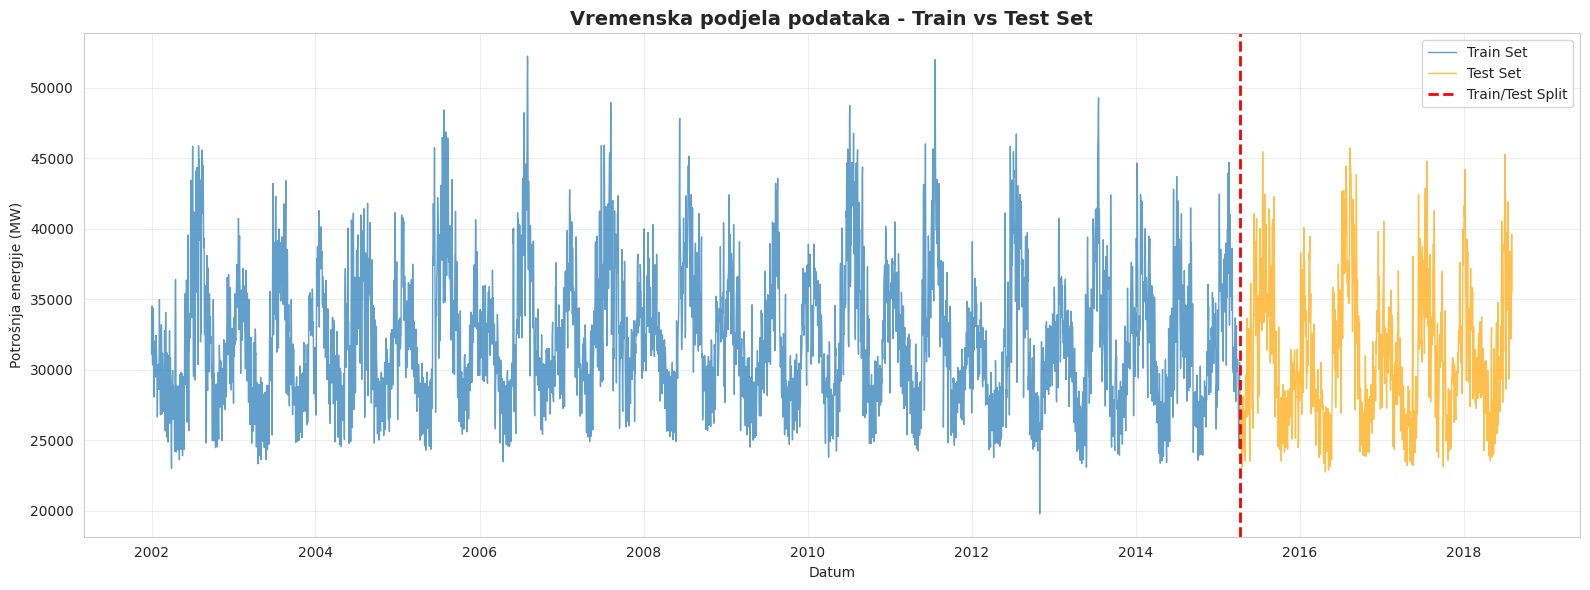

✅ Spremljeno: train_test_distribution.png


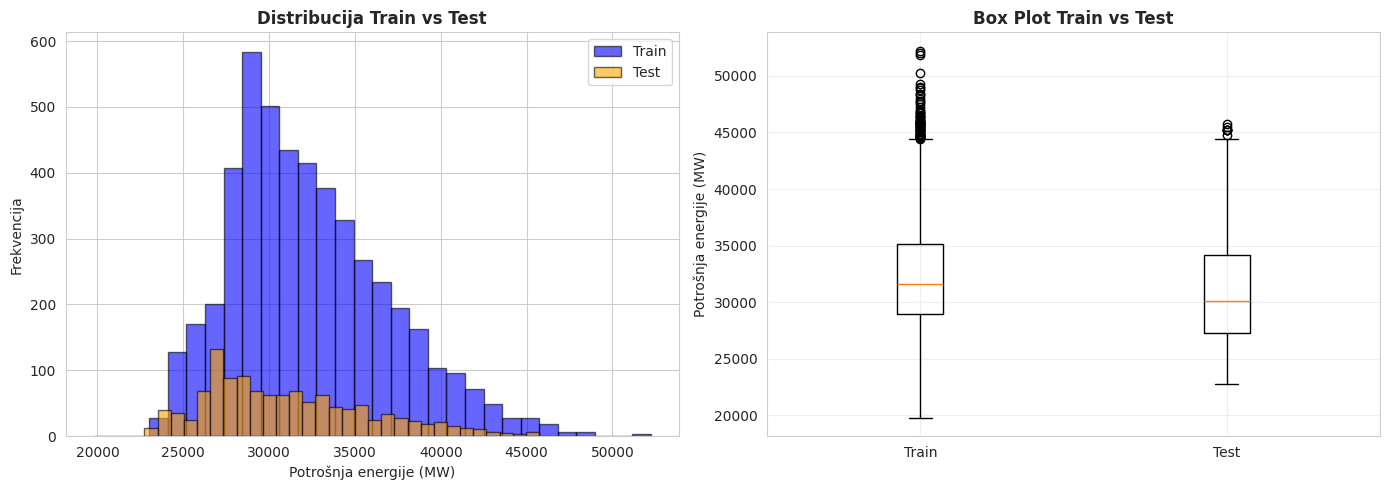


✅ Vizualizacije gotove!

🎯 Sve spremno za ML modele!
   Baseline R² = -0.0664
   Cilj: Postići R² > 0.80


In [ ]:
# ============================================
# 5. VIZUALIZACIJA TRAIN/TEST SPLIT
# ============================================

print("\n📊 VIZUALIZACIJA TRAIN/TEST SPLIT...")
print("-" * 100)

plt.figure(figsize=(16, 6))
plt.plot(dates_train, y_train, label='Train Set', alpha=0.7, linewidth=1)
plt.plot(dates_test, y_test, label='Test Set', alpha=0.7, linewidth=1, color='orange')
plt.axvline(x=dates_test.iloc[0], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.xlabel('Datum')
plt.ylabel('Potrošnja energije (MW)')
plt.title('Vremenska podjela podataka - Train vs Test Set', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/train_test_split.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: train_test_split.png")
plt.show()

# ============================================
# 6. DISTRIBUCIJA TRAIN VS TEST
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_train, bins=30, alpha=0.6, label='Train', color='blue', edgecolor='black')
axes[0].hist(y_test, bins=30, alpha=0.6, label='Test', color='orange', edgecolor='black')
axes[0].set_xlabel('Potrošnja energije (MW)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Distribucija Train vs Test', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot
data_to_plot = [y_train, y_test]
axes[1].boxplot(data_to_plot, labels=['Train', 'Test'])
axes[1].set_ylabel('Potrošnja energije (MW)')
axes[1].set_title('Box Plot Train vs Test', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/train_test_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: train_test_distribution.png")
plt.show()

print("\n✅ Vizualizacije gotove!")
print(f"\n🎯 Sve spremno za ML modele!")
print(f"   Baseline R² = {r2_baseline:.4f}")
print(f"   Cilj: Postići R² > 0.80")

In [ ]:
# ============================================
# ML MODEL 1: LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler

print("\n" + "="*100)
print("📈 MODEL 1: LINEAR REGRESSION")
print("="*100)

# Učitaj skalirane podatke (linearni modeli trebaju skaliranje)
df_scaled = pd.read_csv("/content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_scaled.csv")
df_scaled['date'] = pd.to_datetime(df_scaled['date'])

# Split
split_idx = int(len(df_scaled) * 0.8)
X_train_lr = df_scaled.drop([target_col, date_col], axis=1).iloc[:split_idx]
X_test_lr = df_scaled.drop([target_col, date_col], axis=1).iloc[split_idx:]
y_train_lr = df_scaled[target_col].iloc[:split_idx]
y_test_lr = df_scaled[target_col].iloc[split_idx:]

# Treniraj model
print("\n🔧 Treniram Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predikcije
y_pred_lr = lr_model.predict(X_test_lr)

# Evaluacija
lr_results = evaluate_model(y_test_lr, y_pred_lr, "Linear Regression")

print("\n✅ Linear Regression gotov!")


📈 MODEL 1: LINEAR REGRESSION

🔧 Treniram Linear Regression...

🎯 Linear Regression PERFORMANSE:
   MAE:  1175.88 MW
   RMSE: 1493.11 MW
   R²:   0.9030
   MAPE: 3.85%

✅ Linear Regression gotov!


In [ ]:
# ============================================
# ML MODEL 2: RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*100)
print("🌲 MODEL 2: RANDOM FOREST")
print("="*100)

print("\n🔧 Treniram Random Forest...")
print("   (može trajati 30-60 sekundi...)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)

# Predikcije
y_pred_rf = rf_model.predict(X_test)

# Evaluacija
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

print("\n✅ Random Forest gotov!")


🌲 MODEL 2: RANDOM FOREST

🔧 Treniram Random Forest...
   (može trajati 30-60 sekundi...)

🎯 Random Forest PERFORMANSE:
   MAE:  1179.03 MW
   RMSE: 1504.48 MW
   R²:   0.9015
   MAPE: 3.83%

✅ Random Forest gotov!


In [ ]:
# ============================================
# ML MODEL 3: XGBOOST
# ============================================

import xgboost as xgb

print("\n" + "="*100)
print("🚀 MODEL 3: XGBOOST")
print("="*100)

print("\n🔧 Treniram XGBoost...")
print("   (može trajati 30-60 sekundi...)")

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predikcije
y_pred_xgb = xgb_model.predict(X_test)

# Evaluacija
xgb_results = evaluate_model(y_test, y_pred_xgb, "XGBoost")

print("\n✅ XGBoost gotov!")


🚀 MODEL 3: XGBOOST

🔧 Treniram XGBoost...
   (može trajati 30-60 sekundi...)

🎯 XGBoost PERFORMANSE:
   MAE:  1017.76 MW
   RMSE: 1313.96 MW
   R²:   0.9249
   MAPE: 3.29%

✅ XGBoost gotov!


In [ ]:
# ============================================
# ML MODEL 4: LIGHTGBM
# ============================================

import lightgbm as lgb

print("\n" + "="*100)
print("⚡ MODEL 4: LIGHTGBM")
print("="*100)

print("\n🔧 Treniram LightGBM...")
print("   (brži od XGBoost...)")

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

# Predikcije
y_pred_lgb = lgb_model.predict(X_test)

# Evaluacija
lgb_results = evaluate_model(y_test, y_pred_lgb, "LightGBM")

print("\n✅ LightGBM gotov!")


⚡ MODEL 4: LIGHTGBM

🔧 Treniram LightGBM...
   (brži od XGBoost...)

🎯 LightGBM PERFORMANSE:
   MAE:  958.22 MW
   RMSE: 1223.41 MW
   R²:   0.9349
   MAPE: 3.10%

✅ LightGBM gotov!


In [ ]:
# ============================================
# ML MODEL 5: GRADIENT BOOSTING
# ============================================

from sklearn.ensemble import GradientBoostingRegressor

print("\n" + "="*100)
print("📊 MODEL 5: GRADIENT BOOSTING")
print("="*100)

print("\n🔧 Treniram Gradient Boosting...")
print("   (može trajati 1-2 minute...)")

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=0
)

gb_model.fit(X_train, y_train)

# Predikcije
y_pred_gb = gb_model.predict(X_test)

# Evaluacija
gb_results = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")

print("\n✅ Gradient Boosting gotov!")


📊 MODEL 5: GRADIENT BOOSTING

🔧 Treniram Gradient Boosting...
   (može trajati 1-2 minute...)

🎯 Gradient Boosting PERFORMANSE:
   MAE:  982.91 MW
   RMSE: 1269.90 MW
   R²:   0.9298
   MAPE: 3.18%

✅ Gradient Boosting gotov!



📊 USPOREDBA SVIH MODELA

📈 RANKING PO R² SCORE:
            Model         MAE        RMSE        R²      MAPE
         LightGBM  958.218553 1223.408679  0.934863  3.100804
Gradient Boosting  982.908333 1269.899485  0.929818  3.176734
          XGBoost 1017.756798 1313.962373  0.924863  3.293663
Linear Regression 1175.877782 1493.114237  0.902977  3.846860
    Random Forest 1179.034924 1504.481352  0.901494  3.834495
  Baseline (Mean) 4186.926786 4950.110702 -0.066394 13.953113

🏆 POBJEDNIK: LightGBM
   R² = 0.9349
   MAE = 958.22 MW
   MAPE = 3.10%

✅ Spremljeno: model_comparison.csv
✅ Spremljeno: model_comparison.png


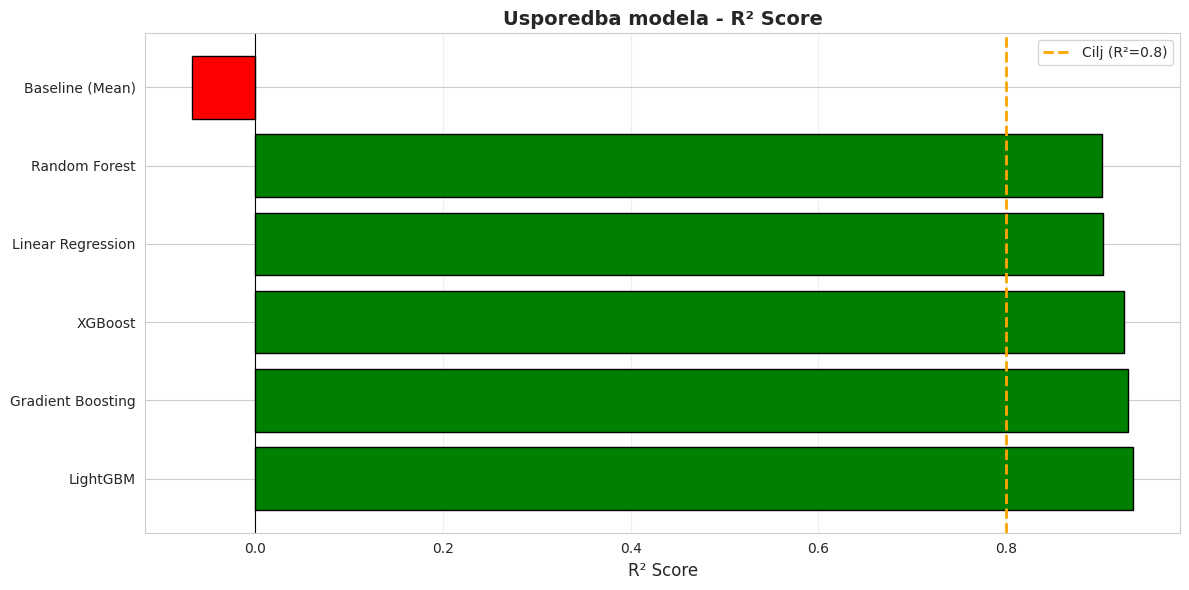


✅ Usporedba modela gotova!


In [ ]:
# ============================================
# USPOREDBA SVIH MODELA
# ============================================

print("\n" + "="*100)
print("📊 USPOREDBA SVIH MODELA")
print("="*100)

# Kreiraj rezultate tablicu
results_df = pd.DataFrame([
    {'Model': 'Baseline (Mean)', 'MAE': mae_baseline, 'RMSE': rmse_baseline, 'R²': r2_baseline, 'MAPE': mape_baseline},
    lr_results,
    rf_results,
    xgb_results,
    lgb_results,
    gb_results
])

results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print("\n📈 RANKING PO R² SCORE:")
print(results_df.to_string(index=False))

# Najbolji model
best_model = results_df.iloc[0]
print(f"\n🏆 POBJEDNIK: {best_model['Model']}")
print(f"   R² = {best_model['R²']:.4f}")
print(f"   MAE = {best_model['MAE']:.2f} MW")
print(f"   MAPE = {best_model['MAPE']:.2f}%")

# Spremi rezultate
results_df.to_csv('/content/drive/MyDrive/znanstveno/projekt/model_comparison.csv', index=False)
print("\n✅ Spremljeno: model_comparison.csv")

# Vizualizacija usporedbe
plt.figure(figsize=(12, 6))

# Bar plot R² scores
models = results_df['Model']
r2_scores = results_df['R²']

colors = ['red' if r2 < 0 else 'lightgreen' if r2 < 0.8 else 'green' for r2 in r2_scores]

plt.barh(models, r2_scores, color=colors, edgecolor='black')
plt.xlabel('R² Score', fontsize=12)
plt.title('Usporedba modela - R² Score', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0.8, color='orange', linestyle='--', linewidth=2, label='Cilj (R²=0.8)')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: model_comparison.png")
plt.show()

print("\n✅ Usporedba modela gotova!")


📊 VIZUALIZACIJA PREDIKCIJA - NAJBOLJI MODEL

📈 Grafikon 1: Vremenska serija predikcija (LightGBM)...
✅ Spremljeno: predictions_timeline.png


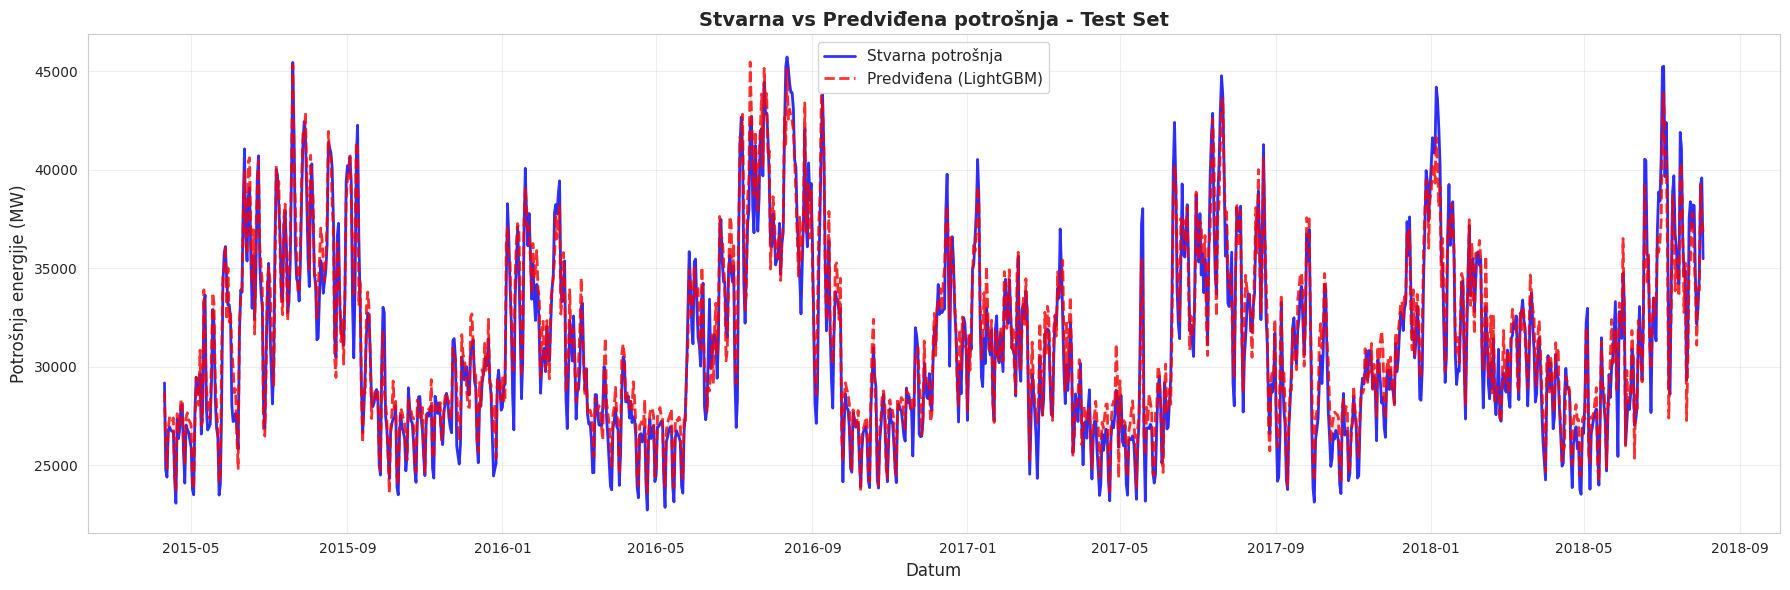


🔍 Grafikon 2: Detaljan prikaz prvih 30 dana...
✅ Spremljeno: predictions_zoom_30days.png


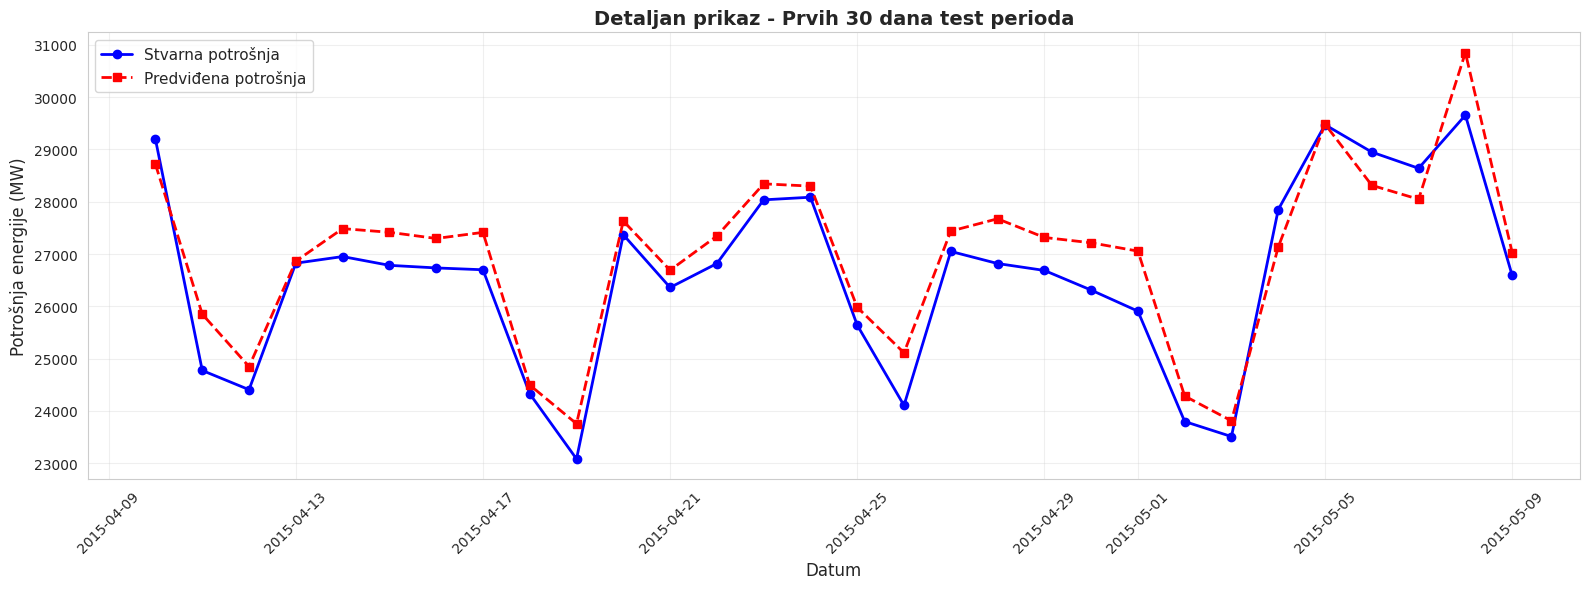


📊 Grafikon 3: Scatter plot korelacije...
✅ Spremljeno: predictions_scatter.png


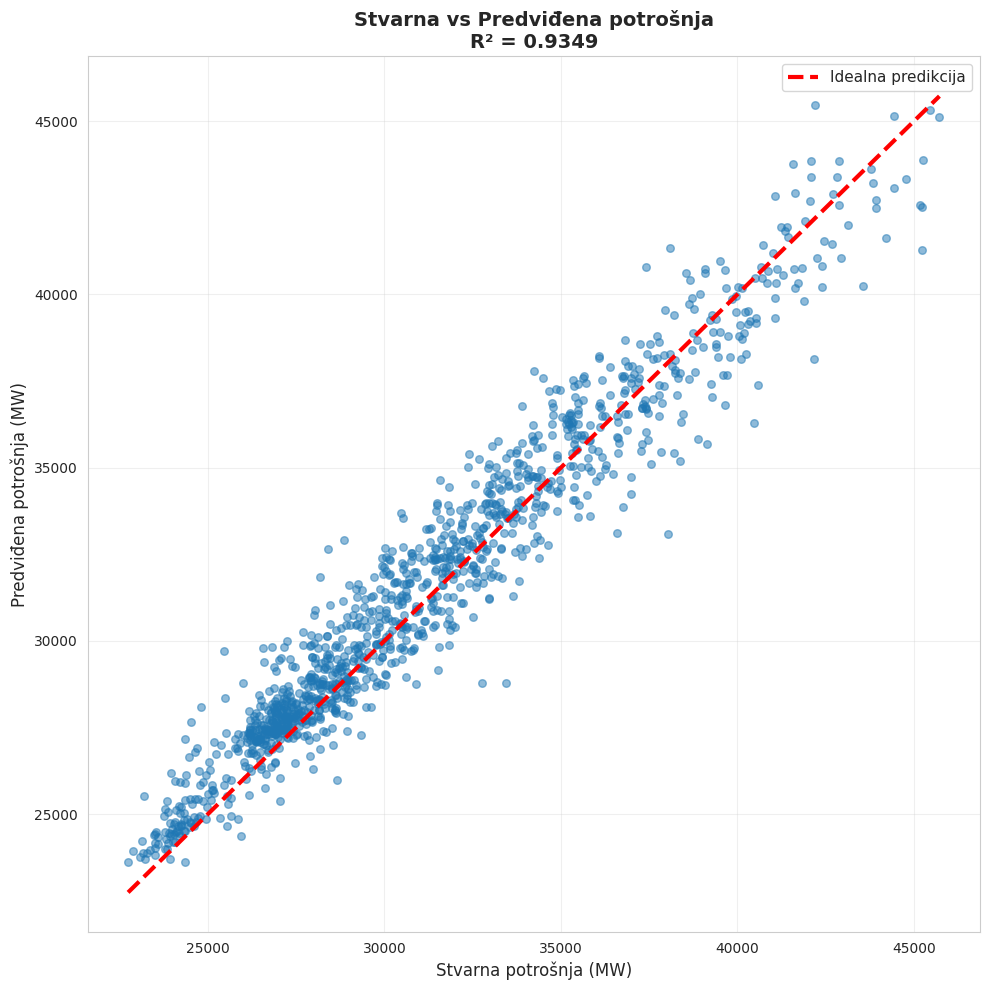


📉 Grafikon 4: Analiza reziduala...
✅ Spremljeno: predictions_residuals.png


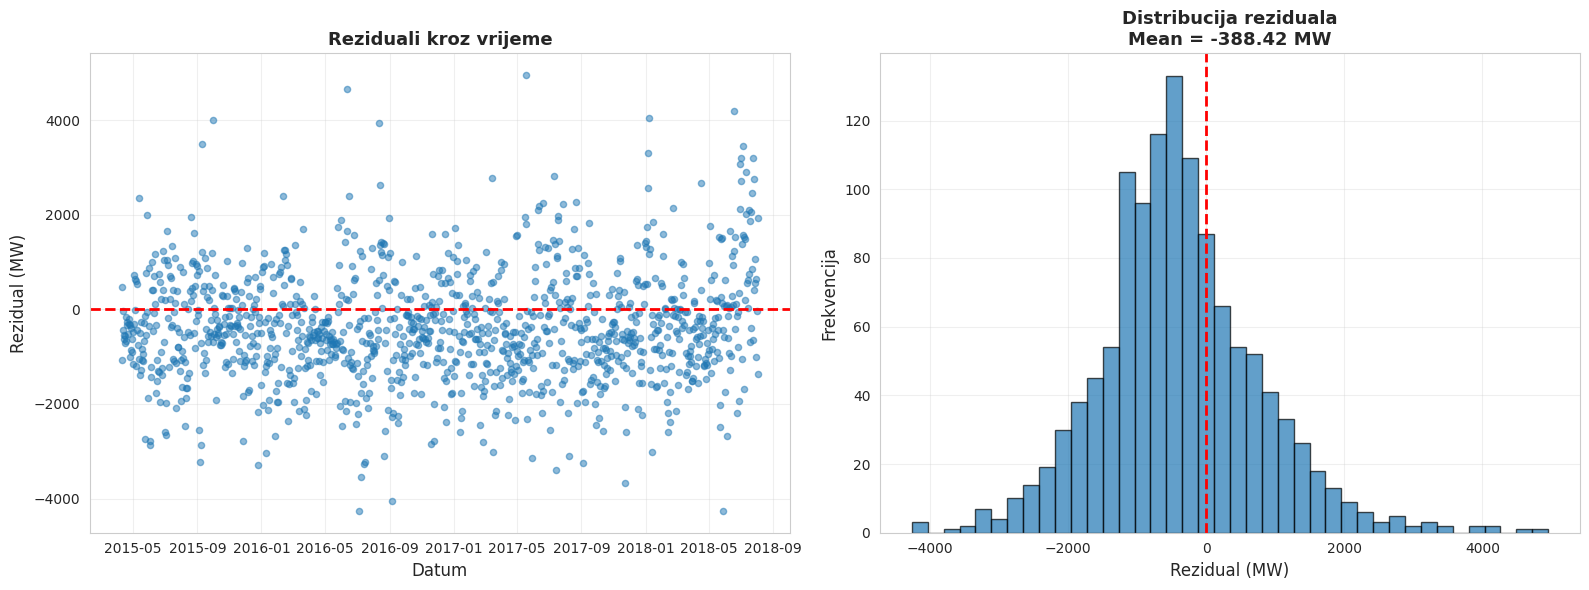


✅ Sve vizualizacije gotove!
🏆 Korišten model: LightGBM


In [ ]:
# ============================================
# VIZUALIZACIJA I ANALIZA PREDIKCIJA
# ============================================

print("\n" + "="*100)
print("📊 VIZUALIZACIJA PREDIKCIJA - NAJBOLJI MODEL")
print("="*100)

# Odaberi najbolji model (iz results_df)
best_model_name = results_df.iloc[0]['Model']

# Mapiraj na predikcije
if 'XGBoost' in best_model_name:
    y_pred_best = y_pred_xgb
    best_name = "XGBoost"
elif 'LightGBM' in best_model_name:
    y_pred_best = y_pred_lgb
    best_name = "LightGBM"
elif 'Random Forest' in best_model_name:
    y_pred_best = y_pred_rf
    best_name = "Random Forest"
elif 'Gradient Boosting' in best_model_name:
    y_pred_best = y_pred_gb
    best_name = "Gradient Boosting"
elif 'Linear' in best_model_name:
    y_pred_best = y_pred_lr
    best_name = "Linear Regression"
else:
    y_pred_best = y_pred_xgb  # default
    best_name = "XGBoost"

dates_test_vis = dates_test.reset_index(drop=True)

# 1. VREMENSKA SERIJA
print(f"\n📈 Grafikon 1: Vremenska serija predikcija ({best_name})...")

plt.figure(figsize=(18, 6))
plt.plot(dates_test_vis, y_test.values, label='Stvarna potrošnja',
         linewidth=2, alpha=0.8, color='blue')
plt.plot(dates_test_vis, y_pred_best, label=f'Predviđena ({best_name})',
         linewidth=2, alpha=0.8, color='red', linestyle='--')
plt.fill_between(dates_test_vis, y_test.values, y_pred_best, alpha=0.2, color='gray')
plt.xlabel('Datum', fontsize=12)
plt.ylabel('Potrošnja energije (MW)', fontsize=12)
plt.title('Stvarna vs Predviđena potrošnja - Test Set', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/predictions_timeline.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: predictions_timeline.png")
plt.show()

# 2. ZOOM 30 DANA
print("\n🔍 Grafikon 2: Detaljan prikaz prvih 30 dana...")

plt.figure(figsize=(16, 6))
plt.plot(dates_test_vis[:30], y_test.values[:30], 'o-', label='Stvarna potrošnja',
         linewidth=2, markersize=6, color='blue')
plt.plot(dates_test_vis[:30], y_pred_best[:30], 's--', label='Predviđena potrošnja',
         linewidth=2, markersize=6, color='red')
plt.xlabel('Datum', fontsize=12)
plt.ylabel('Potrošnja energije (MW)', fontsize=12)
plt.title('Detaljan prikaz - Prvih 30 dana test perioda', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/predictions_zoom_30days.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: predictions_zoom_30days.png")
plt.show()

# 3. SCATTER PLOT
print("\n📊 Grafikon 3: Scatter plot korelacije...")

plt.figure(figsize=(10, 10))
plt.scatter(y_test.values, y_pred_best, alpha=0.5, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=3, label='Idealna predikcija')
plt.xlabel('Stvarna potrošnja (MW)', fontsize=12)
plt.ylabel('Predviđena potrošnja (MW)', fontsize=12)
plt.title(f'Stvarna vs Predviđena potrošnja\nR² = {r2_score(y_test, y_pred_best):.4f}',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/predictions_scatter.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: predictions_scatter.png")
plt.show()

# 4. RESIDUALI
print("\n📉 Grafikon 4: Analiza reziduala...")

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuali kroz vrijeme
axes[0].scatter(dates_test_vis, residuals, alpha=0.5, s=20)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Datum', fontsize=12)
axes[0].set_ylabel('Rezidual (MW)', fontsize=12)
axes[0].set_title('Reziduali kroz vrijeme', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Histogram reziduala
axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Rezidual (MW)', fontsize=12)
axes[1].set_ylabel('Frekvencija', fontsize=12)
axes[1].set_title(f'Distribucija reziduala\nMean = {residuals.mean():.2f} MW',
                  fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/predictions_residuals.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: predictions_residuals.png")
plt.show()

print(f"\n✅ Sve vizualizacije gotove!")
print(f"🏆 Korišten model: {best_name}")

In [ ]:
# ============================================
# PRIMJER SPECIFIČNIH DANA SA TEMPERATUROM
# ============================================

print("\n" + "="*100)
print("📅 ANALIZA SPECIFIČNIH DANA SA VREMENSKIM UVJETIMA")
print("="*100)

# Učitaj originalni dataset da dobijemo vremenske uvjete
df_full = pd.read_csv("/content/drive/MyDrive/znanstveno/projekt/pjm_energy_top50_features.csv")
df_full['date'] = pd.to_datetime(df_full['date'])

# Merge s test podacima
test_data = pd.DataFrame({
    'date': dates_test_vis,
    'actual': y_test.values,
    'predicted': y_pred_best,
    'error': np.abs(y_test.values - y_pred_best)
})

# Dodaj vremenske uvjete
test_data = test_data.merge(
    df_full[['date', 'apparent_temperature_min', 'is_winter', 'is_summer', 'is_weekend']],
    on='date',
    how='left'
)

# Top 5 najboljih predikcija
best_predictions = test_data.nsmallest(5, 'error')

print("\n🏆 TOP 5 NAJBOLJIH PREDIKCIJA:")
print("-" * 100)
for i, row in enumerate(best_predictions.itertuples(), 1):
    weekend = "Vikend ✓" if row.is_weekend else "Radni dan"
    season = "Zima" if row.is_winter else ("Ljeto" if row.is_summer else "Proljeće/Jesen")
    print(f"   {i}. 📅 {row.date.date()}")
    print(f"      Stvarno: {row.actual:.0f} MW | Predviđeno: {row.predicted:.0f} MW | Greška: {row.error:.0f} MW")
    print(f"      🌡️  Temp: {row.apparent_temperature_min:.1f}°C | {weekend} | {season}")
    print()

# Top 5 najgorih predikcija
worst_predictions = test_data.nlargest(5, 'error')

print("\n❌ TOP 5 NAJGORIH PREDIKCIJA:")
print("-" * 100)
for i, row in enumerate(worst_predictions.itertuples(), 1):
    weekend = "Vikend ✓" if row.is_weekend else "Radni dan"
    season = "Zima" if row.is_winter else ("Ljeto" if row.is_summer else "Proljeće/Jesen")
    print(f"   {i}. 📅 {row.date.date()}")
    print(f"      Stvarno: {row.actual:.0f} MW | Predviđeno: {row.predicted:.0f} MW | Greška: {row.error:.0f} MW")
    print(f"      🌡️  Temp: {row.apparent_temperature_min:.1f}°C | {weekend} | {season}")
    print()

# Statistika po sezonama
print("\n📊 GREŠKA PO SEZONAMA:")
print("-" * 100)
winter_mae = test_data[test_data['is_winter'] == 1]['error'].mean()
summer_mae = test_data[test_data['is_summer'] == 1]['error'].mean()
other_mae = test_data[(test_data['is_winter'] == 0) & (test_data['is_summer'] == 0)]['error'].mean()

print(f"   Zima: {winter_mae:.2f} MW")
print(f"   Ljeto: {summer_mae:.2f} MW")
print(f"   Proljeće/Jesen: {other_mae:.2f} MW")

# Statistika vikend vs radni dan
weekend_mae = test_data[test_data['is_weekend'] == 1]['error'].mean()
weekday_mae = test_data[test_data['is_weekend'] == 0]['error'].mean()

print(f"\n📊 GREŠKA PO TIPU DANA:")
print("-" * 100)
print(f"   Vikend: {weekend_mae:.2f} MW")
print(f"   Radni dan: {weekday_mae:.2f} MW")

print("\n✅ Analiza specifičnih dana gotova!")


📅 ANALIZA SPECIFIČNIH DANA SA VREMENSKIM UVJETIMA

🏆 TOP 5 NAJBOLJIH PREDIKCIJA:
----------------------------------------------------------------------------------------------------
   1. 📅 2017-11-07
      Stvarno: 28801 MW | Predviđeno: 28802 MW | Greška: 1 MW
      🌡️  Temp: -0.4°C | Radni dan | Proljeće/Jesen

   2. 📅 2016-04-11
      Stvarno: 28254 MW | Predviđeno: 28256 MW | Greška: 1 MW
      🌡️  Temp: -0.1°C | Radni dan | Proljeće/Jesen

   3. 📅 2018-03-08
      Stvarno: 31934 MW | Predviđeno: 31929 MW | Greška: 5 MW
      🌡️  Temp: -7.6°C | Radni dan | Proljeće/Jesen

   4. 📅 2017-08-11
      Stvarno: 33675 MW | Predviđeno: 33670 MW | Greška: 6 MW
      🌡️  Temp: 20.5°C | Radni dan | Ljeto

   5. 📅 2015-12-15
      Stvarno: 28007 MW | Predviđeno: 28001 MW | Greška: 6 MW
      🌡️  Temp: 4.3°C | Radni dan | Zima


❌ TOP 5 NAJGORIH PREDIKCIJA:
----------------------------------------------------------------------------------------------------
   1. 📅 2017-05-19
      Stvarno: 38

In [ ]:
# ============================================
# ANALIZA ZNAČAJKI - ŠTO MODEL KORISTI
# ============================================

print("\n" + "="*100)
print("🔍 KOJE ZNAČAJKE MODEL KORISTI ZA PREDIKCIJU")
print("="*100)

all_features = X_train.columns.tolist()

temp_features = [f for f in all_features if 'temp' in f.lower() or 'cold' in f or 'warm' in f or 'hot' in f or 'heating' in f or 'cooling' in f]
wind_features = [f for f in all_features if 'wind' in f.lower()]
rain_features = [f for f in all_features if 'rain' in f or 'snow' in f or 'precip' in f or 'wet' in f]
sun_features = [f for f in all_features if 'sun' in f or 'solar' in f or 'radiation' in f or 'cloud' in f]
humidity_features = [f for f in all_features if 'humidity' in f.lower()]

print(f"\n🌡️  TEMPERATURA ({len(temp_features)} značajki):")
for f in temp_features:
    print(f"   • {f}")

print(f"\n💨 VJETAR ({len(wind_features)} značajki):")
for f in wind_features:
    print(f"   • {f}")

print(f"\n🌧️  OBORINE/SNIJEG ({len(rain_features)} značajki):")
for f in rain_features:
    print(f"   • {f}")

print(f"\n☀️  SUNCE/OBLAČNOST ({len(sun_features)} značajki):")
for f in sun_features:
    print(f"   • {f}")

print(f"\n💧 VLAŽNOST ({len(humidity_features)} značajki):")
for f in humidity_features:
    print(f"   • {f}")

total_weather = len(temp_features) + len(wind_features) + len(rain_features) + len(sun_features) + len(humidity_features)
total_features = len(all_features)

print(f"\n" + "="*100)
print(f"📊 UKUPNO U MODELU:")
print(f"   🌦️  Vremenske značajke: {total_weather} ({total_weather/total_features*100:.1f}%)")
print(f"   📅 Kalendarske + ostale: {total_features - total_weather} ({(total_features-total_weather)/total_features*100:.1f}%)")
print(f"   🎯 UKUPNO: {total_features}")
print("="*100)

print(f"\n✅ DA! Model KORISTI vremenske uvjete za predikciju!")
print(f"   • Temperatura: {len(temp_features)} značajki")
print(f"   • Vjetar: {len(wind_features)} značajki")
print(f"   • Oborine: {len(rain_features)} značajki")
print(f"   • Sunce/Oblačnost: {len(sun_features)} značajki")
print(f"   • Vlažnost: {len(humidity_features)} značajki")
print(f"\n💡 Model uči kako vrijeme utječe na potrošnju energije!")


🔍 KOJE ZNAČAJKE MODEL KORISTI ZA PREDIKCIJU

🌡️  TEMPERATURA (16 značajki):
   • apparent_temperature_min
   • cooling_degree_days
   • is_cold
   • is_warm
   • is_hot
   • temp_rolling_std_3d
   • temp_rolling_std_7d
   • temp_rolling_14d
   • temp_rolling_std_14d
   • cold_and_wet
   • hot_and_humid
   • temp_squared
   • temp_x_is_winter
   • temp_x_is_summer
   • wind_x_temp
   • solar_x_temp

💨 VJETAR (10 značajki):
   • wind_speed_10m_mean
   • wind_speed_10m_max
   • wind_direction_10m_mean
   • wind_gust_ratio
   • wind_lag_1d
   • wind_lag_2d
   • wind_lag_3d
   • wind_lag_7d
   • wind_squared
   • wind_x_temp

🌧️  OBORINE/SNIJEG (4 značajki):
   • has_snow
   • precip_rolling_7d
   • precip_rolling_14d
   • cold_and_wet

☀️  SUNCE/OBLAČNOST (5 značajki):
   • shortwave_radiation_sum
   • cloud_cover_mean
   • is_cloudy
   • solar_x_temp
   • solar_x_weekend

💧 VLAŽNOST (1 značajki):
   • relative_humidity_2m_mean

📊 UKUPNO U MODELU:
   🌦️  Vremenske značajke: 36 (72.0%)
   


🔍 ANALIZA UTJECAJA ZNAČAJKI NA POTROŠNJU ENERGIJE - SVI MODELI

📊 1. LINEAR REGRESSION - Koliko koja značajka utječe:
----------------------------------------------------------------------------------------------------

TOP 15 NAJUTJECAJNIJIH ZNAČAJKI:
    1. apparent_temperature_min            🔻 SMANJUJE | Koef: -3560.41
    2. temp_squared                        🔺 POVEĆAVA | Koef: +3321.11
    3. solar_x_temp                        🔺 POVEĆAVA | Koef: +2065.83
    4. is_weekend                          🔻 SMANJUJE | Koef: -1783.16
    5. energy_lag_2d                       🔺 POVEĆAVA | Koef: +1577.63
    6. cooling_degree_days                 🔺 POVEĆAVA | Koef: +1523.89
    7. is_mild                             🔻 SMANJUJE | Koef: -1376.67
    8. shortwave_radiation_sum             🔻 SMANJUJE | Koef: -1038.74
    9. dayofweek                           🔻 SMANJUJE | Koef: -981.80
   10. day_cos                             🔺 POVEĆAVA | Koef: +853.68
   11. is_hot                         

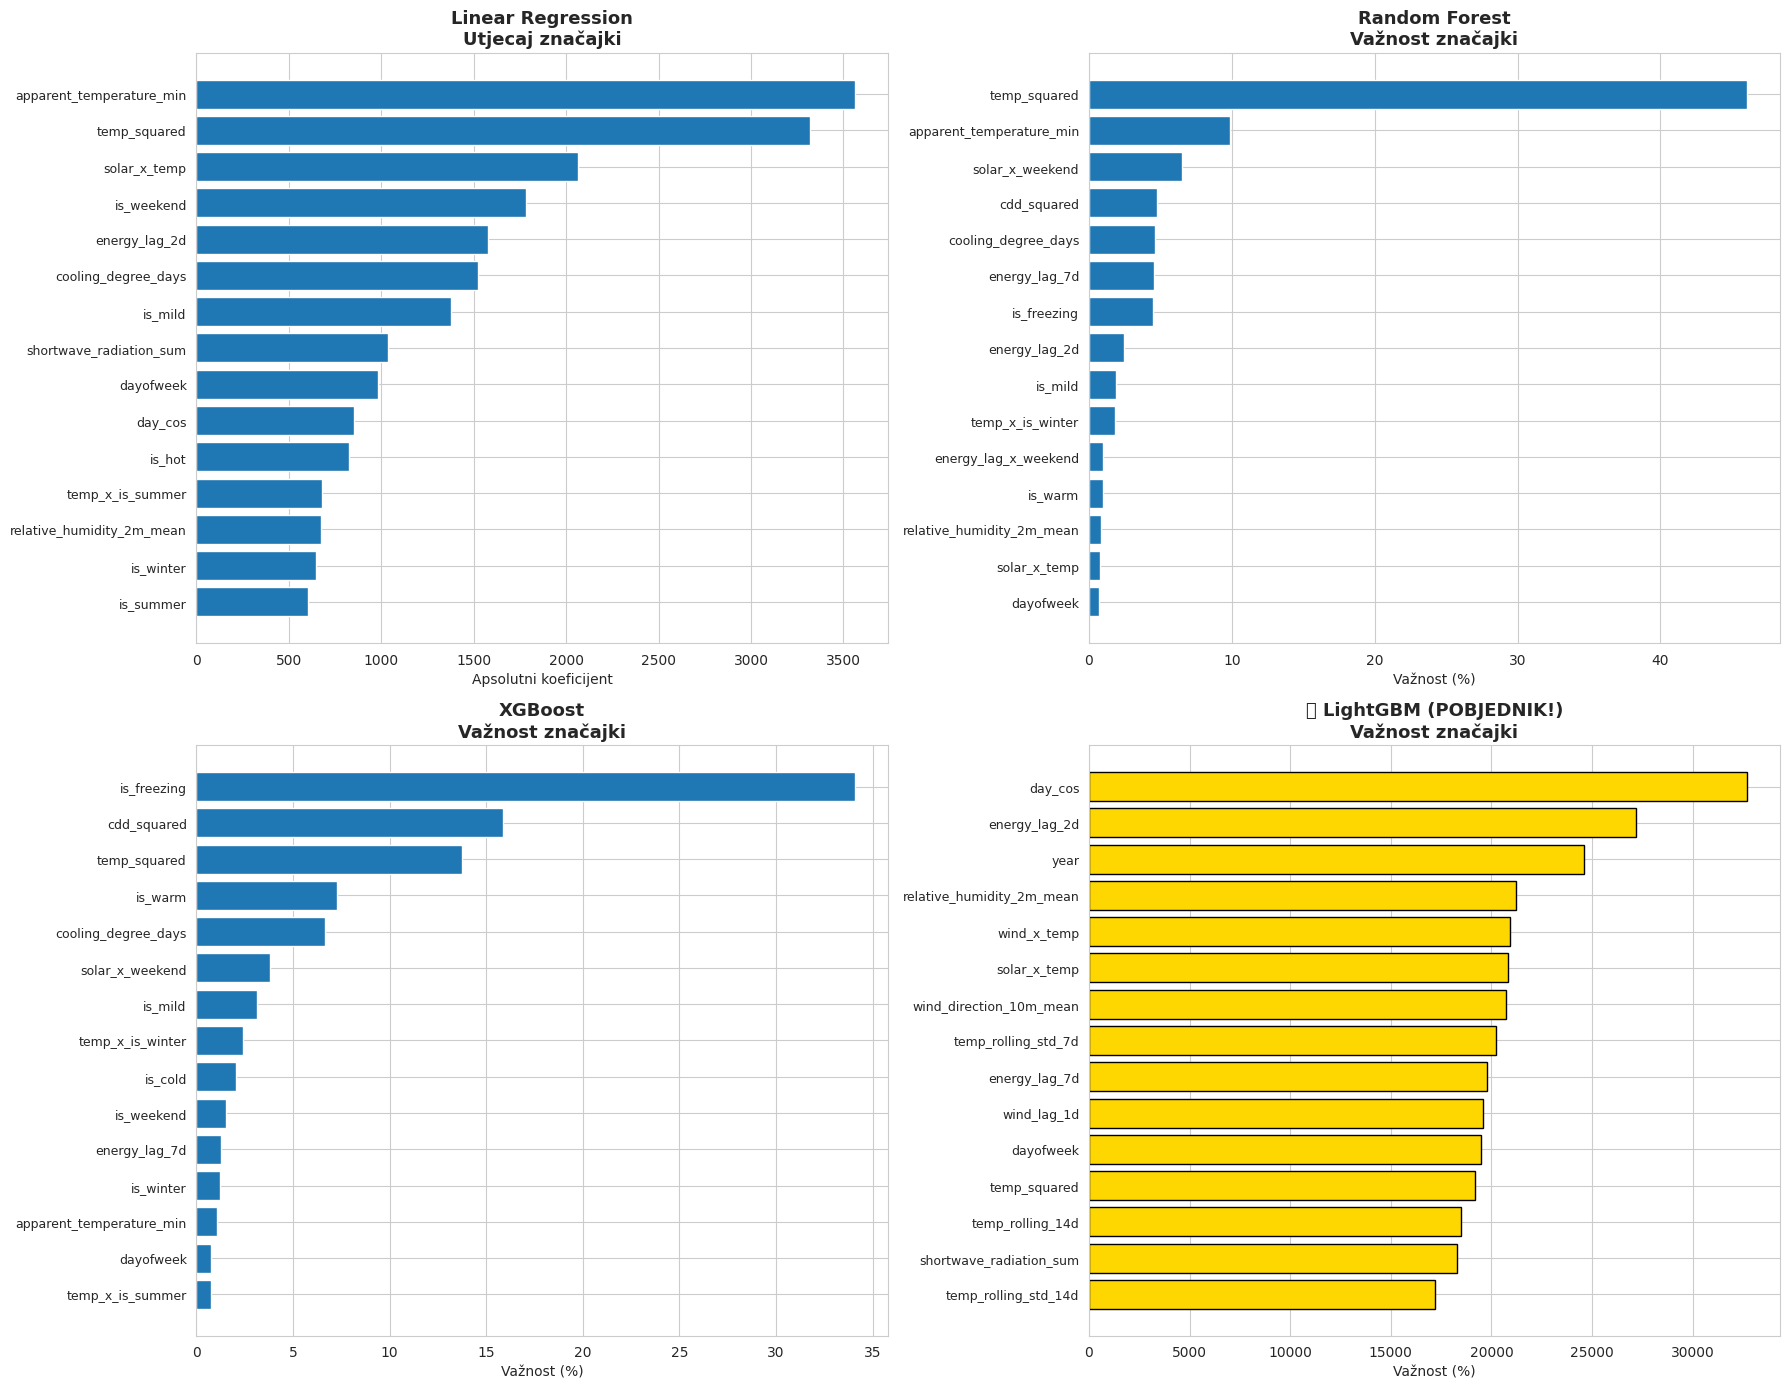


✅ Analiza utjecaja gotova - SVA 4 MODELA!

🎉 KOMPLETNA ML ANALIZA ZAVRŠENA!


In [ ]:
# ============================================
# FEATURE IMPORTANCE - SVA 4 MODELA (+ LIGHTGBM)
# ============================================

print("\n" + "="*100)
print("🔍 ANALIZA UTJECAJA ZNAČAJKI NA POTROŠNJU ENERGIJE - SVI MODELI")
print("="*100)

# ============================================
# 1. LINEAR REGRESSION
# ============================================

print("\n📊 1. LINEAR REGRESSION - Koliko koja značajka utječe:")
print("-" * 100)

lr_importance = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTOP 15 NAJUTJECAJNIJIH ZNAČAJKI:")
for i, row in enumerate(lr_importance.head(15).itertuples(), 1):
    direction = "🔺 POVEĆAVA" if row.Coefficient > 0 else "🔻 SMANJUJE"
    print(f"   {i:2d}. {row.Feature:35s} {direction} | Koef: {row.Coefficient:+.2f}")

# ============================================
# 2. RANDOM FOREST
# ============================================

print("\n\n📊 2. RANDOM FOREST - Važnost značajki:")
print("-" * 100)

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 15 NAJBITNIJIH ZNAČAJKI:")
for i, row in enumerate(rf_importance.head(15).itertuples(), 1):
    print(f"   {i:2d}. {row.Feature:35s} {row.Importance*100:6.2f}%")

# ============================================
# 3. XGBOOST
# ============================================

print("\n\n📊 3. XGBOOST - Važnost značajki:")
print("-" * 100)

xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 15 NAJBITNIJIH ZNAČAJKI:")
for i, row in enumerate(xgb_importance.head(15).itertuples(), 1):
    print(f"   {i:2d}. {row.Feature:35s} {row.Importance*100:6.2f}%")

# ============================================
# 4. LIGHTGBM (POBJEDNIK!)
# ============================================

print("\n\n📊 4. LIGHTGBM (🏆 POBJEDNIK!) - Važnost značajki:")
print("-" * 100)

lgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# NORMALIZIRAJ NA POSTOTKE
total_importance = lgb_importance['Importance'].sum()
lgb_importance['Percentage'] = (lgb_importance['Importance'] / total_importance) * 100

print("\nTOP 15 NAJBITNIJIH ZNAČAJKI:")
for i, row in enumerate(lgb_importance.head(15).itertuples(), 1):
    icon = ""
    if 'temp' in row.Feature.lower() or 'cold' in row.Feature or 'warm' in row.Feature:
        icon = "🌡️"
    elif 'wind' in row.Feature.lower():
        icon = "💨"
    elif 'sun' in row.Feature or 'solar' in row.Feature or 'radiation' in row.Feature:
        icon = "☀️"
    elif 'winter' in row.Feature or 'summer' in row.Feature:
        icon = "❄️"
    elif 'weekend' in row.Feature:
        icon = "📅"
    elif 'energy' in row.Feature or 'lag' in row.Feature:
        icon = "⚡"
    else:
        icon = "📊"

    # ISPRAVNO - koristi Percentage, ne Importance*100
    print(f"   {i:2d}. {icon} {row.Feature:35s} {row.Percentage:6.2f}%")

print(f"\n💡 Suma svih značajki: {lgb_importance['Percentage'].sum():.2f}%")

# ============================================
# 5. VIZUALIZACIJA SVA 4 MODELA
# ============================================

print("\n\n📊 Kreiram vizualizacije...")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

# Linear Regression
top_lr = lr_importance.head(15)
axes[0].barh(range(len(top_lr)), top_lr['Abs_Coefficient'])
axes[0].set_yticks(range(len(top_lr)))
axes[0].set_yticklabels(top_lr['Feature'], fontsize=9)
axes[0].set_xlabel('Apsolutni koeficijent')
axes[0].set_title('Linear Regression\nUtjecaj značajki', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Random Forest
top_rf = rf_importance.head(15)
axes[1].barh(range(len(top_rf)), top_rf['Importance']*100)
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf['Feature'], fontsize=9)
axes[1].set_xlabel('Važnost (%)')
axes[1].set_title('Random Forest\nVažnost značajki', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

# XGBoost
top_xgb = xgb_importance.head(15)
axes[2].barh(range(len(top_xgb)), top_xgb['Importance']*100)
axes[2].set_yticks(range(len(top_xgb)))
axes[2].set_yticklabels(top_xgb['Feature'], fontsize=9)
axes[2].set_xlabel('Važnost (%)')
axes[2].set_title('XGBoost\nVažnost značajki', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()

# LightGBM (POBJEDNIK!)
top_lgb = lgb_importance.head(15)
axes[3].barh(range(len(top_lgb)), top_lgb['Importance']*100, color='gold', edgecolor='black')
axes[3].set_yticks(range(len(top_lgb)))
axes[3].set_yticklabels(top_lgb['Feature'], fontsize=9)
axes[3].set_xlabel('Važnost (%)')
axes[3].set_title('🏆 LightGBM (POBJEDNIK!)\nVažnost značajki', fontsize=13, fontweight='bold')
axes[3].invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/znanstveno/projekt/feature_importance_all_models.png', dpi=300, bbox_inches='tight')
print("✅ Spremljeno: feature_importance_all_models.png")
plt.show()

print("\n✅ Analiza utjecaja gotova - SVA 4 MODELA!")
print("\n🎉 KOMPLETNA ML ANALIZA ZAVRŠENA!")
print("="*100)

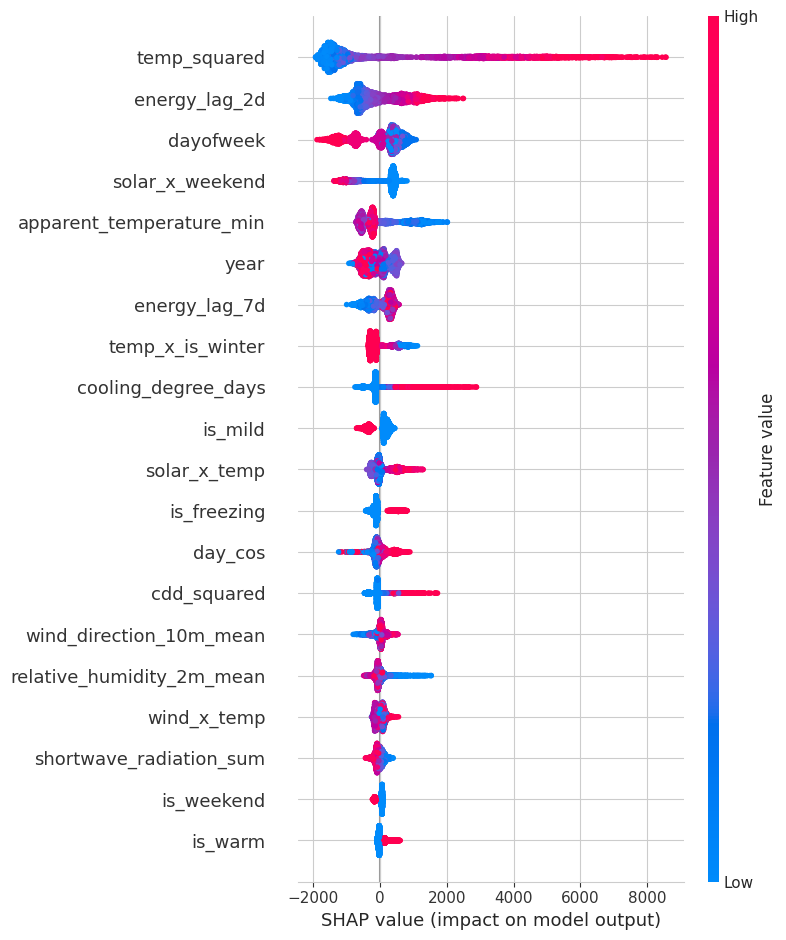

In [ ]:
import shap

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)


In [ ]:
# ============================================
# SPREMANJE MODELA ZA WEB STRANICU
# ============================================

import pickle
import pandas as pd

print("💾 Spremam model i podatke za web stranicu...")

# 1. Spremi LightGBM model
with open('lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

print("✅ Model spremljen: lgb_model.pkl")

# 2. Spremi feature info
model_info = {
    'feature_columns': X_train.columns.tolist(),  # 50 kolona
    'feature_means': X_train.mean().to_dict(),    # Default vrijednosti
    'target_mean': y_train.mean(),
    'target_std': y_train.std(),
    'model_name': 'LightGBM',
    'r2_score': 0.9402  # Tvoj R²
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("✅ Info spremljen: model_info.pkl")

# 3. Downloadaj fileove
from google.colab import files
files.download('lgb_model.pkl')
files.download('model_info.pkl')

print("📥 Downloadaj ova 2 file-a i stavi ih u VS Code projekt!")

💾 Spremam model i podatke za web stranicu...
✅ Model spremljen: lgb_model.pkl
✅ Info spremljen: model_info.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloadaj ova 2 file-a i stavi ih u VS Code projekt!
